# Global Life Expectancy — Machine Learning Capstone
## Review 1: Regression + Classification Part A

**Course:** 23CSE301 Machine Learning  
**Academic Year:** 2026–27  
**Review:** Review 1

| Item | Choice |
|---|---|
| **Correct dataset** | **Life Expectancy (WHO) — Kumarajarshi/Kaggle original dataset** |
| **Dataset size before cleaning** | 2,938 rows × 22 columns |
| **Regression target** | Life_expectancy |
| **Classification target** | Status — Developed / Developing |
| **Regression algorithms** | All 10 required algorithms |
| **Classification algorithms** | Part A — 5 required algorithms |
| **Dimensionality reduction** | PCA, fitted on training data only |

### Review-1 pipeline

**Raw data → audit → EDA → train/test split → train-only imputation/outlier treatment/encoding/scaling → PCA → 10 regression models + 5 classification models → comparison → tuning → cross-validation → diagnostics → conclusions**

**Dataset source:** https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

In [42]:
# ============================================================
# 1. IMPORTS AND GLOBAL SETTINGS
# ============================================================

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE = 0.20
PCA_VARIANCE = 0.95

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11, 'figure.titlesize': 15})

print('Libraries loaded.')
print(f'Random state: {RANDOM_STATE}')
print(f'Test size: {TEST_SIZE:.0%}')
print(f'PCA retained variance target: {PCA_VARIANCE:.0%}')

Libraries loaded.
Random state: 42
Test size: 20%
PCA retained variance target: 95%


## Section A — Dataset Loading & Audit

The first task is to prove that the selected dataset really contains the required mixture of categorical and numerical data and genuine missing values.

We standardise column names only for easier Python use. No observations are changed at this stage.

In [43]:
# ============================================================
# 2. LOAD THE LIFE EXPECTANCY DATASET
# ============================================================

# Upload the original "Life Expectancy Data.csv"

DATA_PATH = "/content/Life Expectancy Data.csv"

df_raw = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)
print(f"File: {DATA_PATH}")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")
print("=" * 70)

display(df_raw.head())

DATASET LOADED SUCCESSFULLY
File: /content/Life Expectancy Data.csv
Rows: 2942
Columns: 22


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [44]:
# ============================================================
# 3. STANDARDISE COLUMN NAMES
# ============================================================

df = df_raw.copy()
df.columns = df.columns.str.strip()

rename_map = {
    'Life expectancy': 'Life_expectancy',
    'Adult Mortality': 'Adult_Mortality',
    'infant deaths': 'Infant_deaths',
    'percentage expenditure': 'Percentage_expenditure',
    'Hepatitis B': 'Hepatitis_B',
    'under-five deaths': 'Under_five_deaths',
    'Total expenditure': 'Total_expenditure',
    'HIV/AIDS': 'HIV_AIDS',
    'thinness 1-19 years': 'Thinness_1_19_years',
    'thinness 5-9 years': 'Thinness_5_9_years',
    'Income composition of resources': 'Income_composition_of_resources'
}

df = df.rename(columns=rename_map)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

numeric_candidates = [c for c in df.columns if c not in ['Country', 'Status']]
for col in numeric_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Standardised columns:')
print(df.columns.tolist())

Standardised columns:
['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'Infant_deaths', 'Alcohol', 'Percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'Under_five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Thinness_5_9_years', 'Income_composition_of_resources', 'Schooling']


In [45]:
# ============================================================
# 4. DATA TYPES + CATEGORICAL/NUMERICAL AUDIT
# ============================================================

categorical_cols_raw = df.select_dtypes(include='object').columns.tolist()
numeric_cols_raw = df.select_dtypes(include=np.number).columns.tolist()

audit_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.astype(str).values,
    'Missing_Count': df.isna().sum().values,
    'Missing_%': (df.isna().mean().mul(100)).round(2).values,
    'Unique_Values': df.nunique(dropna=True).values
})

print('Categorical columns:')
print(categorical_cols_raw)
print('\\nNumerical columns:')
print(numeric_cols_raw)
display(audit_df)

assert 'Status' in categorical_cols_raw
assert 'Life_expectancy' in numeric_cols_raw
assert len(categorical_cols_raw) >= 1 and len(numeric_cols_raw) >= 1

display(Markdown(
    f'**Dataset requirement check:** the raw dataset contains **{len(categorical_cols_raw)} categorical** '
    f'and **{len(numeric_cols_raw)} numerical** columns. The categorical variable `Status` will be encoded for regression and used as the classification target.'
))

Categorical columns:
['Country', 'Status']
\nNumerical columns:
['Year', 'Life_expectancy', 'Adult_Mortality', 'Infant_deaths', 'Alcohol', 'Percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'Under_five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'Thinness_5_9_years', 'Income_composition_of_resources', 'Schooling']


,Column,Dtype,Missing_Count,Missing_%,Unique_Values
0,Country,object,0,0.00,193
1,Year,int64,0,0.00,16
2,Status,object,0,0.00,2
3,Life_expectancy,float64,10,0.34,362
4,Adult_Mortality,float64,10,0.34,425
5,Infant_deaths,int64,0,0.00,209
6,Alcohol,float64,194,6.59,1076
7,Percentage_expenditure,float64,0,0.00,2328
8,Hepatitis_B,float64,553,18.80,87
9,Measles,int64,0,0.00,958


**Dataset requirement check:** the raw dataset contains **2 categorical** and **20 numerical** columns. The categorical variable `Status` will be encoded for regression and used as the classification target.

Number of columns containing missing values: 14


,Missing_Count,Missing_Percent
Population,652,22.16
Hepatitis_B,553,18.80
GDP,448,15.23
Total_expenditure,226,7.68
Alcohol,194,6.59
Income_composition_of_resources,167,5.68
Schooling,163,5.54
Thinness_5_9_years,34,1.16
thinness 1-19 years,34,1.16
BMI,34,1.16


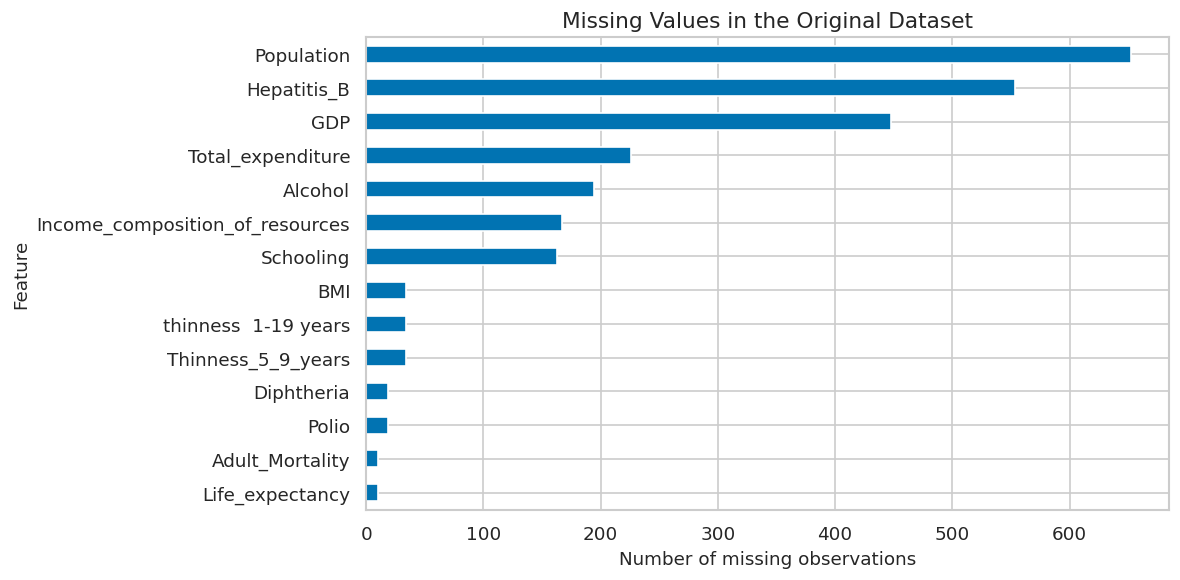

**Observation:** Missing values are genuinely present in the original dataset. They are not replaced during EDA. Imputation is postponed until after the train/test split so statistics from the test set cannot leak into training.

In [46]:
# ============================================================
# 5. MISSING-VALUE AUDIT
# ============================================================

# Median Imputation
missing_df = (
    df.isna().sum().rename('Missing_Count').to_frame()
    .assign(Missing_Percent=lambda x: (x['Missing_Count'] / len(df) * 100).round(2))
    .query('Missing_Count > 0').sort_values('Missing_Count', ascending=False)
)

print(f'Number of columns containing missing values: {len(missing_df)}')
display(missing_df)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Missing_Count'].sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Missing Values in the Original Dataset')
    ax.set_xlabel('Number of missing observations')
    ax.set_ylabel('Feature')
    plt.tight_layout(); plt.show()

display(Markdown(
    '**Observation:** Missing values are genuinely present in the original dataset. '
    'They are not replaced during EDA. Imputation is postponed until after the train/test split '
    'so statistics from the test set cannot leak into training.'
))

In [47]:
# ============================================================
# 6. DUPLICATE AUDIT
# ============================================================

duplicate_count = df.duplicated().sum()
print(f'Duplicate rows before cleaning: {duplicate_count}')
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape after duplicate removal: {df.shape}')
else:
    print('No duplicate rows were removed.')

Duplicate rows before cleaning: 4
Shape after duplicate removal: (2938, 22)


Regression target: Life_expectancy


,Life_expectancy
count,2928.00
mean,69.22
std,9.52
min,36.30
25%,63.10
50%,72.10
75%,75.70
max,89.00


\nClassification target: Status


,Count
Status,
Developing,2426
Developed,512


,Percentage
Status,
Developing,82.57
Developed,17.43


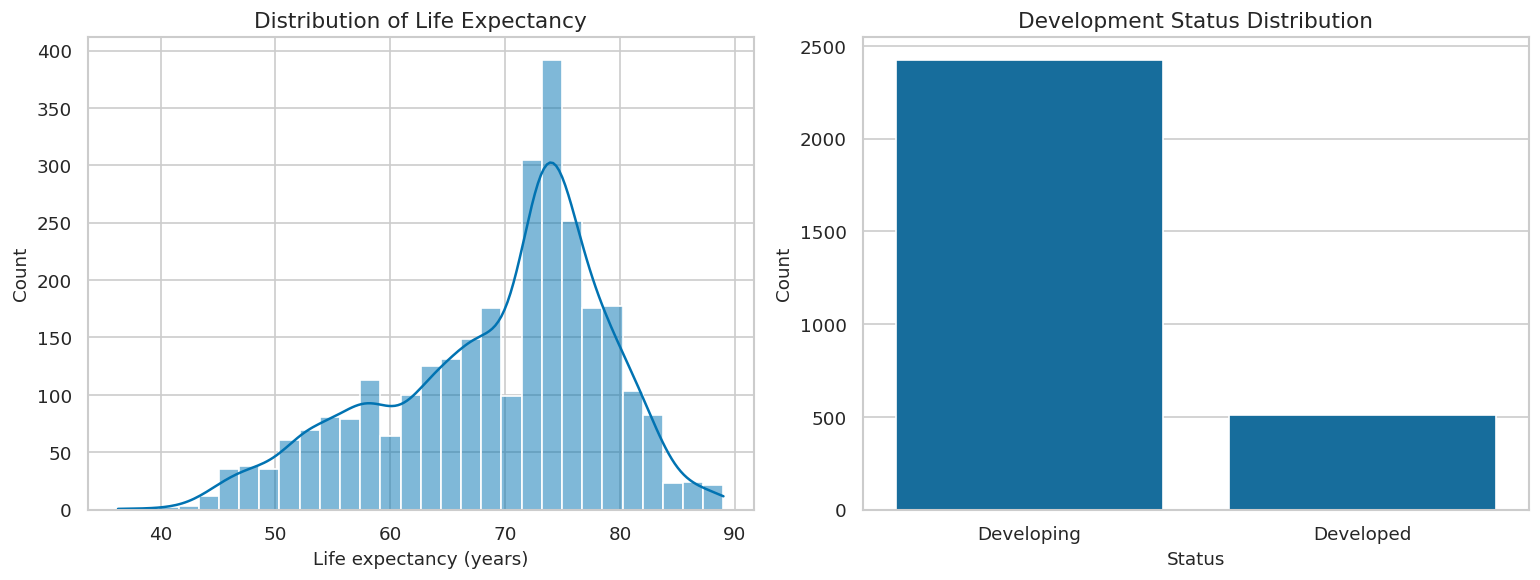

In [48]:
# ============================================================
# 7. TARGET AND CLASS DISTRIBUTION
# ============================================================

print('Regression target: Life_expectancy')
display(df['Life_expectancy'].describe().round(2))

print('\\nClassification target: Status')
status_counts = df['Status'].value_counts(dropna=False)
display(status_counts.to_frame('Count'))
display((status_counts / len(df) * 100).round(2).to_frame('Percentage'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['Life_expectancy'].dropna(), kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Life Expectancy')
axes[0].set_xlabel('Life expectancy (years)')
axes[0].set_ylabel('Count')
sns.countplot(data=df, x='Status', ax=axes[1])
axes[1].set_title('Development Status Distribution')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

### A1 Observation

The audit establishes the three points that matter for Review 1:

1. The dataset has both categorical and numerical attributes.
2. Missing values are present and therefore require a justified treatment.
3. `Life_expectancy` is a continuous regression target, while `Status` provides a natural binary classification target.

The original `Country` column is retained for EDA but will not be used directly as a model feature because it is a high-cardinality identifier rather than a useful low-dimensional categorical predictor.

### A2 — EDA Visualisations

The following cells cover the required feature distributions, correlation heatmap, target distribution, and feature–target scatter plots.

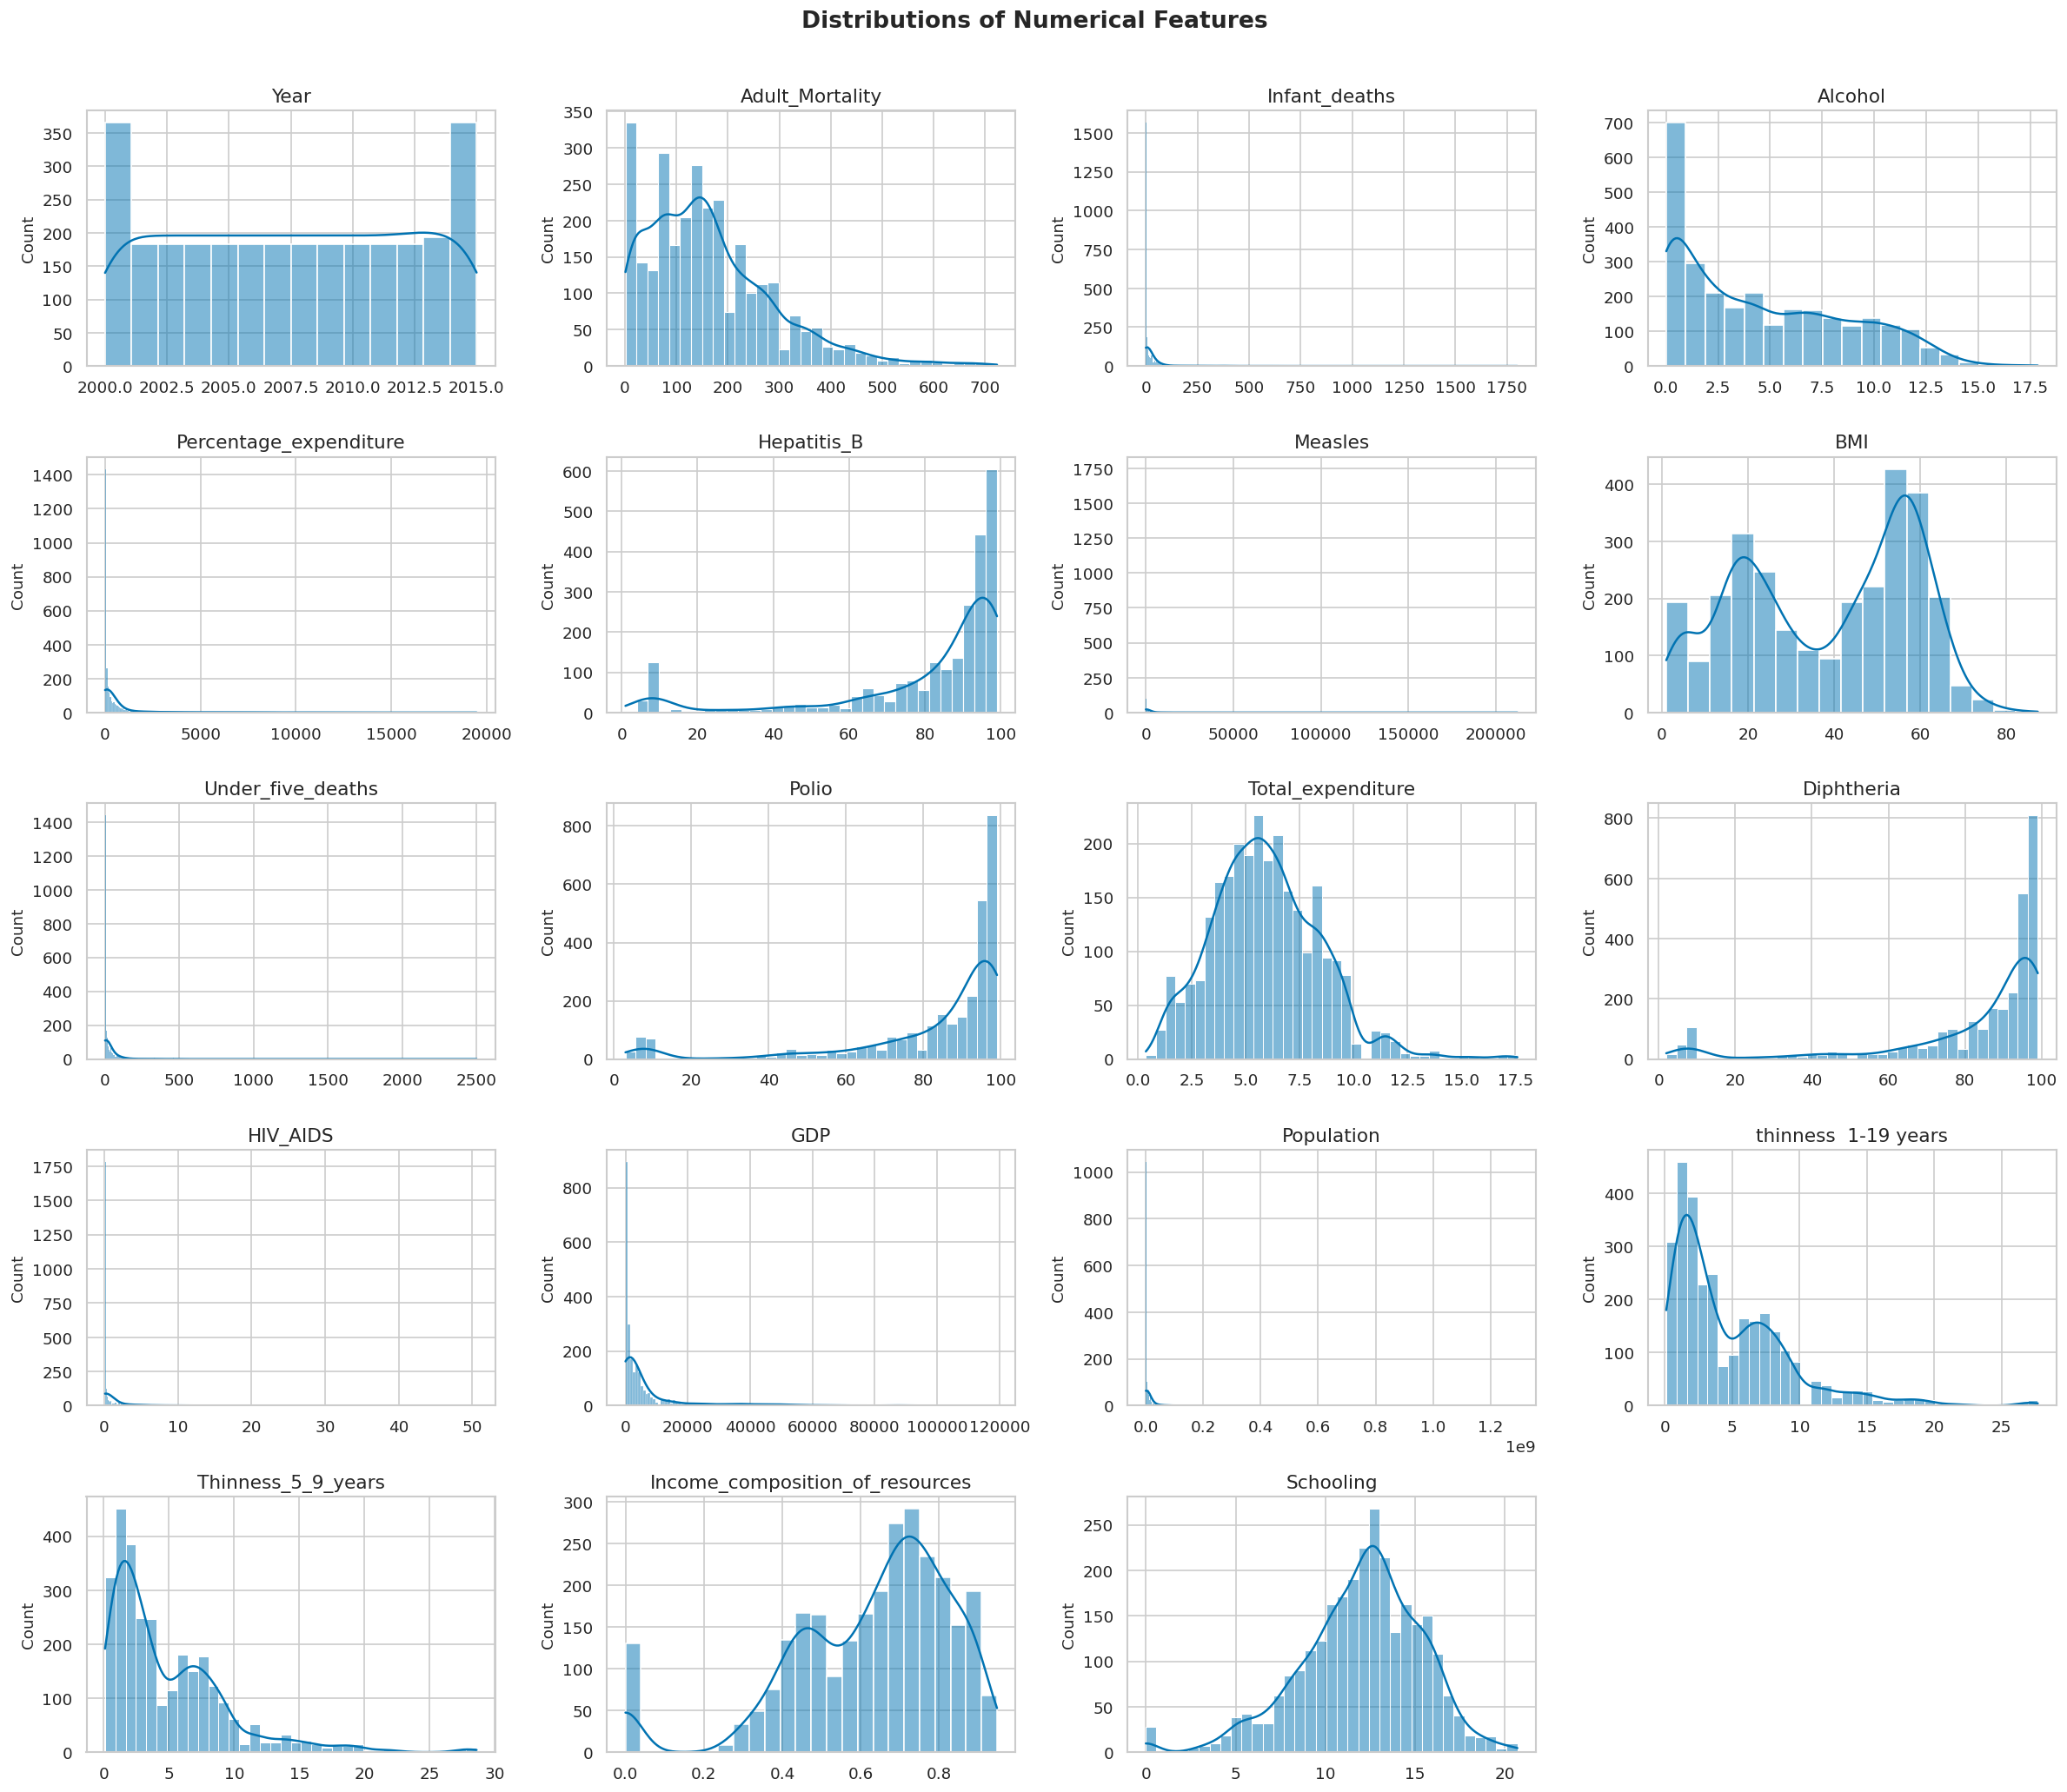

In [49]:
# ============================================================
# 8. DISTRIBUTIONS OF ALL NUMERICAL FEATURES
# ============================================================

eda_numeric = [c for c in numeric_cols_raw if c != 'Life_expectancy']
n_cols = 4
n_rows = int(np.ceil(len(eda_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.4))
axes = np.asarray(axes).flatten()

for i, col in enumerate(eda_numeric):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
for j in range(len(eda_numeric), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Distributions of Numerical Features', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

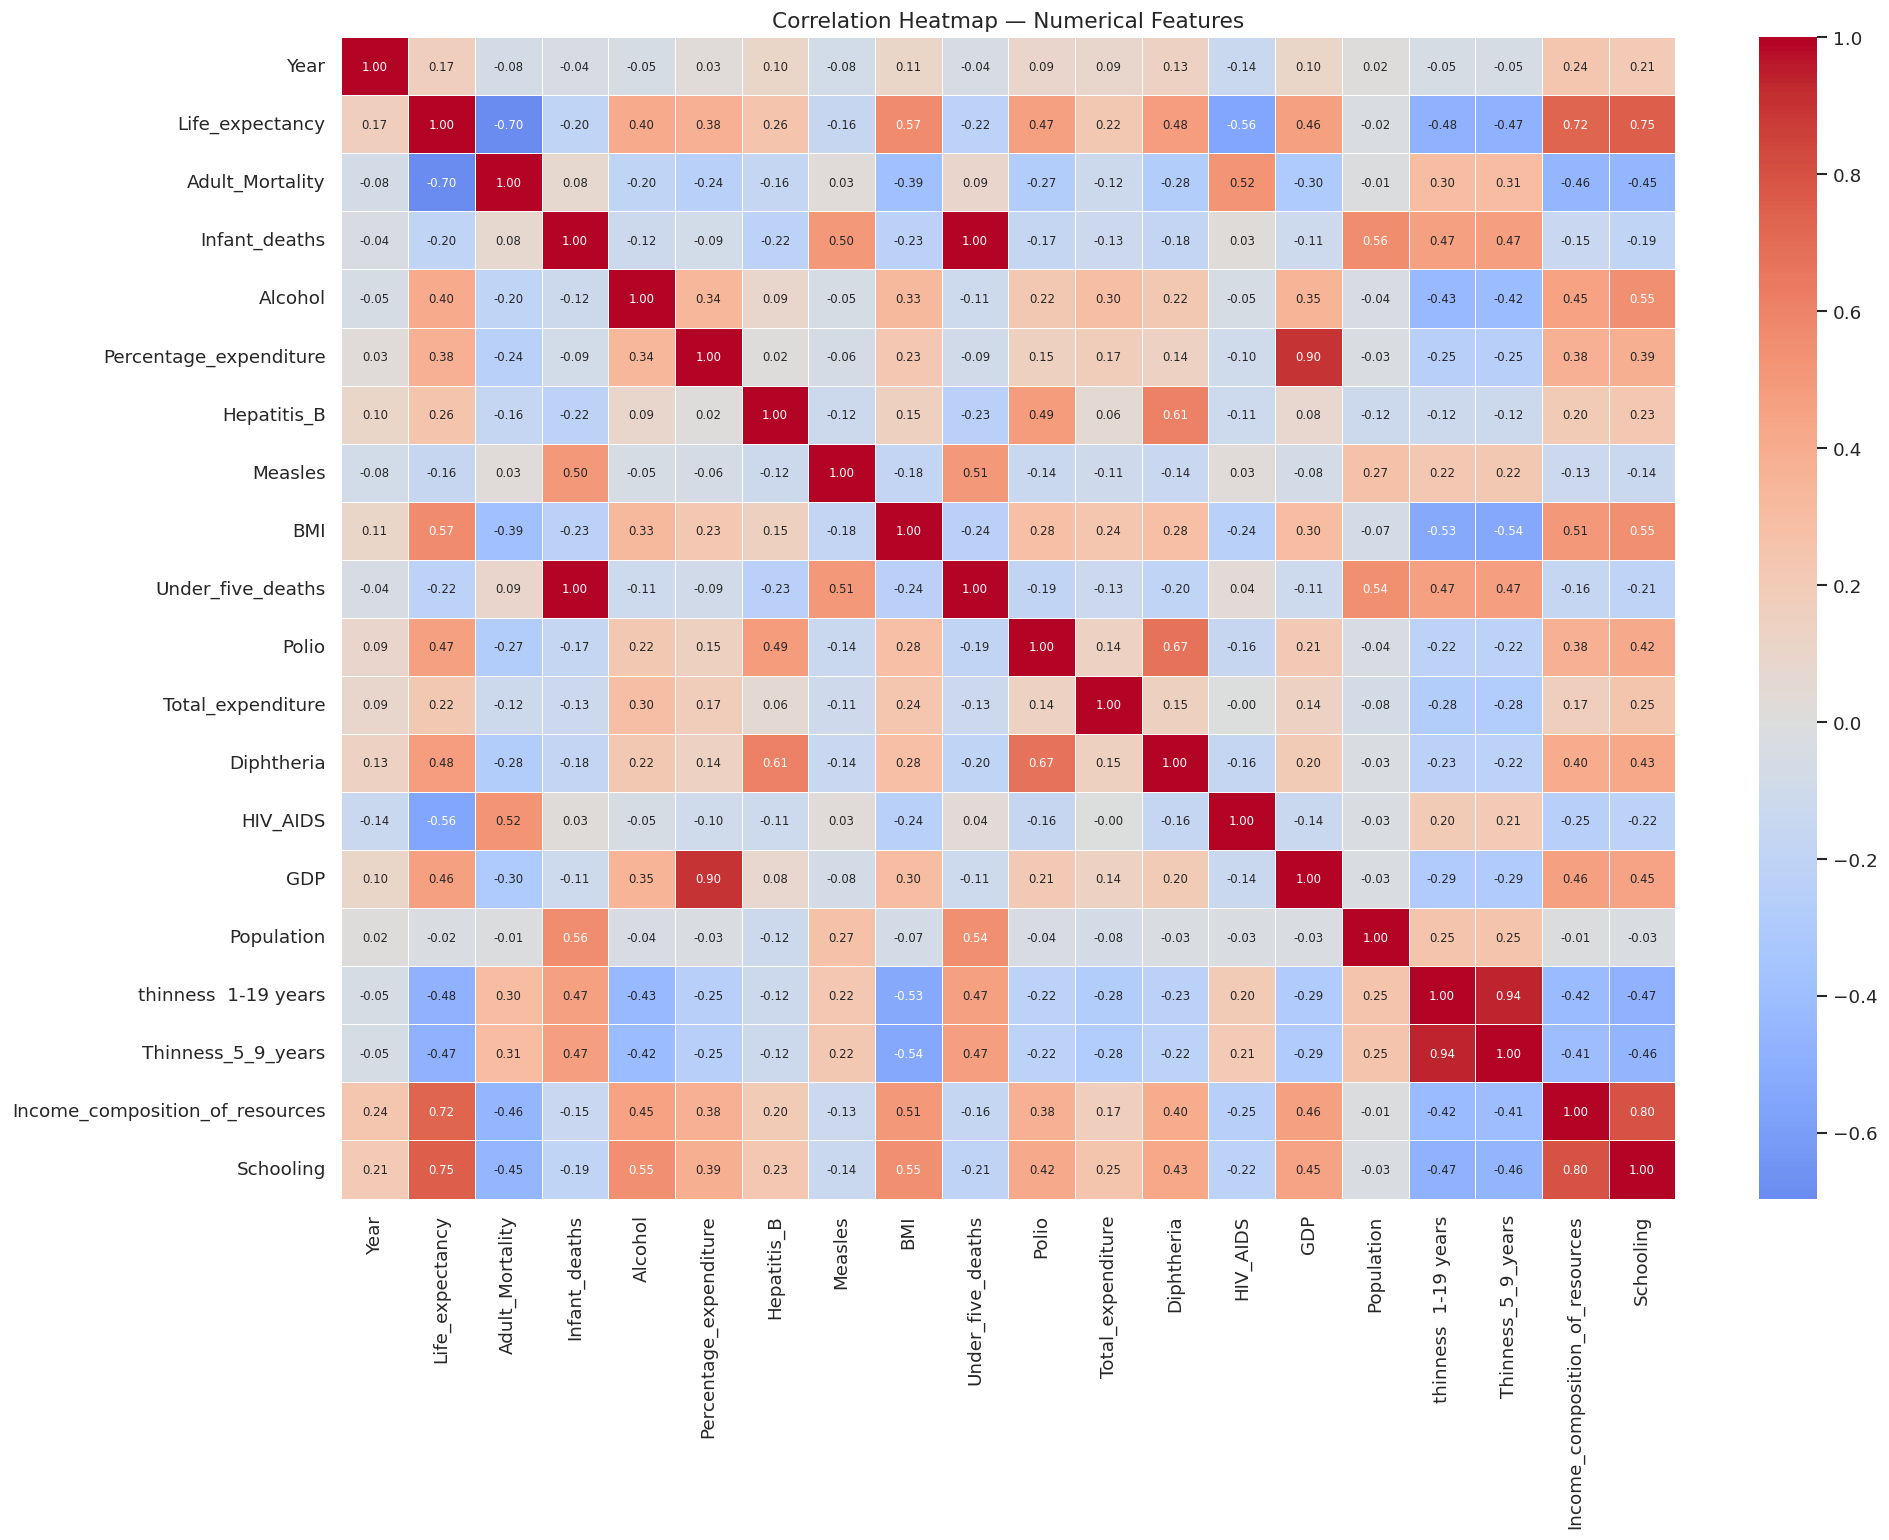

,Correlation_with_Life_expectancy
Schooling,0.751975
Income_composition_of_resources,0.724776
Adult_Mortality,-0.696359
BMI,0.567694
HIV_AIDS,-0.556556
Diphtheria,0.479495
thinness 1-19 years,-0.477183
Thinness_5_9_years,-0.471584
Polio,0.465556
GDP,0.461455


In [50]:
# ============================================================
# 9. CORRELATION HEATMAP
# ============================================================

corr = df[numeric_cols_raw].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(17, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout(); plt.show()

target_corr = corr['Life_expectancy'].drop('Life_expectancy').sort_values(key=lambda s: s.abs(), ascending=False)
display(target_corr.to_frame('Correlation_with_Life_expectancy').head(10))

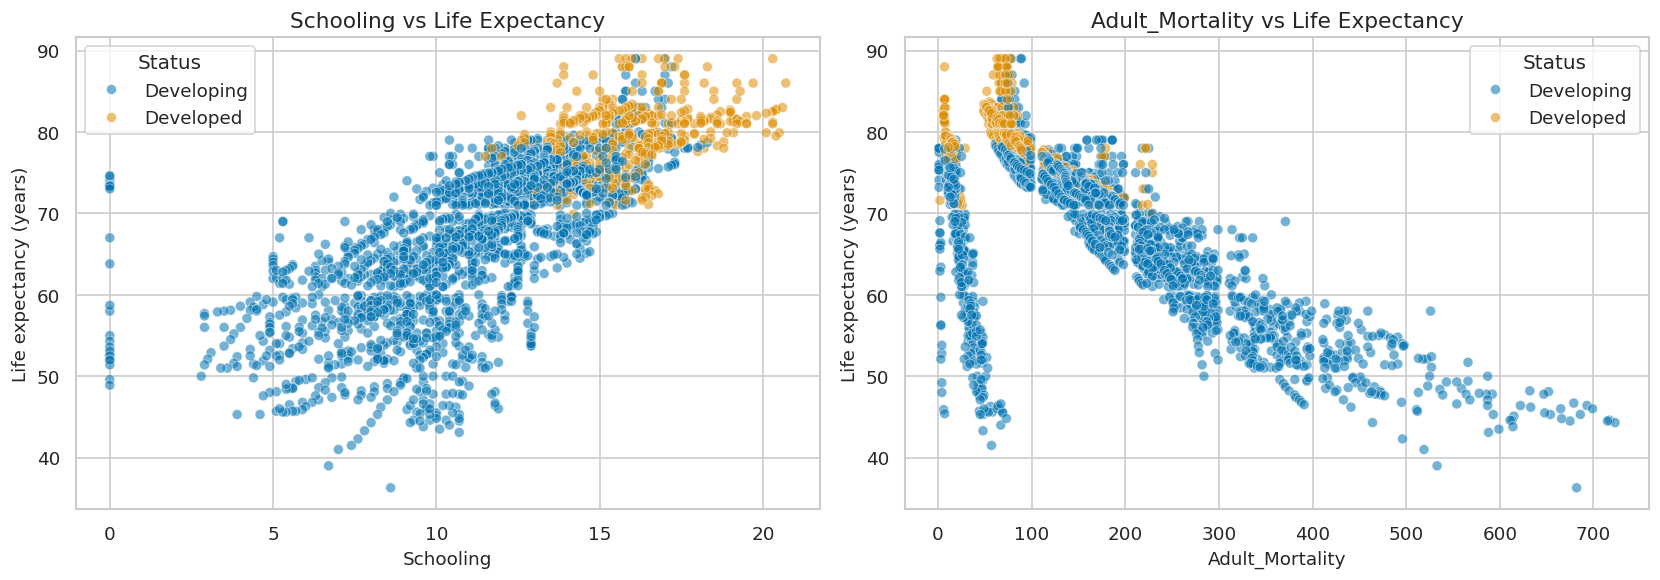

Schooling: Pearson correlation = 0.752 (positive)
Adult_Mortality: Pearson correlation = -0.696 (negative)


In [51]:
# ============================================================
# 10. TWO REQUIRED FEATURE–TARGET SCATTER PLOTS
# ============================================================

scatter_features = ['Schooling', 'Adult_Mortality']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feature in zip(axes, scatter_features):
    sns.scatterplot(data=df, x=feature, y='Life_expectancy', hue='Status', alpha=0.55, ax=ax)
    ax.set_title(f'{feature} vs Life Expectancy')
    ax.set_xlabel(feature)
    ax.set_ylabel('Life expectancy (years)')
plt.tight_layout(); plt.show()

for feature in scatter_features:
    valid = df[[feature, 'Life_expectancy']].dropna()
    r = valid[feature].corr(valid['Life_expectancy'])
    direction = 'positive' if r > 0 else 'negative'
    print(f'{feature}: Pearson correlation = {r:.3f} ({direction})')

### A2 Observation

Use the computed statistics printed with the plots when presenting the findings. A positive correlation means higher values tend to occur with higher life expectancy; a negative correlation means the opposite. Correlation is not proof of causation, and the scatter plots are also used to inspect nonlinearity, clusters, and outliers.

## Section B — Preprocessing & Feature Engineering

### Leakage rule

The preprocessing pipeline is fitted **only on the training data**.

**Median imputation → IQR outlier capping → encoding → StandardScaler → PCA**

This means imputation statistics, outlier thresholds, category encodings, scaling parameters and PCA components are all learned from training data only.

In [52]:
# ============================================================
# 11. FEATURE ENGINEERING
# ============================================================

df_model = df.copy()
df_model['Mortality_Burden'] = (df_model['Adult_Mortality'] + df_model['Infant_deaths']) / 2
df_model['Immunization_Score'] = (df_model['Hepatitis_B'] + df_model['Polio'] + df_model['Diphtheria']) / 3

display(df_model[['Mortality_Burden', 'Immunization_Score']].describe().round(2))
display(Markdown(
    '**Feature-engineering justification:** `Mortality_Burden` combines mortality signals from different age groups, '
    'while `Immunization_Score` summarises three related vaccination coverage measures. Both are created row-by-row and do not use the target or test set.'
))

,Mortality_Burden,Immunization_Score
count,2928.00,2385.00
mean,97.60,83.54
std,89.04,19.15
min,0.50,7.00
25%,39.50,76.00
50%,78.00,92.67
75%,133.50,96.67
max,1012.00,99.00


**Feature-engineering justification:** `Mortality_Burden` combines mortality signals from different age groups, while `Immunization_Score` summarises three related vaccination coverage measures. Both are created row-by-row and do not use the target or test set.

In [53]:
# ============================================================
# 12. DEFINE TRACK DATASETS
# ============================================================

reg_df = df_model.dropna(subset=['Life_expectancy']).copy()
clf_df = df_model.dropna(subset=['Status']).copy()

# Country is kept for EDA but dropped from modelling because it is a high-cardinality identifier.
reg_drop = ['Life_expectancy', 'Country']
clf_drop = ['Status', 'Country']

X_reg = reg_df.drop(columns=reg_drop)
y_reg = reg_df['Life_expectancy']
X_clf = clf_df.drop(columns=clf_drop)
y_clf = clf_df['Status'].map({'Developing': 0, 'Developed': 1})

print(f'Regression dataset: X={X_reg.shape}, y={y_reg.shape}')
print(f'Classification dataset: X={X_clf.shape}, y={y_clf.shape}')
print('\\nClassification target mapping: Developing=0, Developed=1')
print(y_clf.value_counts(dropna=False))

Regression dataset: X=(2928, 22), y=(2928,)
Classification dataset: X=(2938, 22), y=(2938,)
\nClassification target mapping: Developing=0, Developed=1
Status
0    2426
1     512
Name: count, dtype: int64


In [54]:
# ============================================================
# 13. TRAIN/TEST SPLITS
# ============================================================

# Regression: stratify by target quantile bins to preserve target distribution.
reg_bins = pd.qcut(y_reg, q=10, duplicates='drop')
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=reg_bins
)

# Classification: direct stratification by class label.
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_clf
)

print('Regression split:')
print(f'  Train: {X_reg_train.shape}')
print(f'  Test : {X_reg_test.shape}')
print('\\nClassification split:')
print(f'  Train: {X_clf_train.shape}')
print(f'  Test : {X_clf_test.shape}')
print('\\nClassification proportions:')
print('Train:'); print(y_clf_train.value_counts(normalize=True).round(3))
print('Test:'); print(y_clf_test.value_counts(normalize=True).round(3))

Regression split:
  Train: (2342, 22)
  Test : (586, 22)
\nClassification split:
  Train: (2350, 22)
  Test : (588, 22)
\nClassification proportions:
Train:
Status
0    0.826
1    0.174
Name: proportion, dtype: float64
Test:
Status
0    0.827
1    0.173
Name: proportion, dtype: float64


In [55]:
# ============================================================
# 14. TRAIN-ONLY OUTLIER AUDIT + IQR CLIPPER
# ============================================================

class IQRClipper(BaseEstimator, TransformerMixin):
    # Caps numerical values at train-derived IQR bounds.
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(float)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(float)
        return X_df.clip(self.lower_, self.upper_, axis=1).to_numpy()

reg_numeric_for_audit = X_reg_train.select_dtypes(include=np.number).columns.tolist()
audit_imputer = SimpleImputer(strategy='median')
X_reg_train_num_imp = audit_imputer.fit_transform(X_reg_train[reg_numeric_for_audit])
audit_clipper = IQRClipper().fit(X_reg_train_num_imp)
audit_matrix = pd.DataFrame(X_reg_train_num_imp, columns=reg_numeric_for_audit)

outlier_counts = {}
for idx, col in enumerate(reg_numeric_for_audit):
    outlier_counts[col] = int(((audit_matrix[col] < audit_clipper.lower_[idx]) | (audit_matrix[col] > audit_clipper.upper_[idx])).sum())

outlier_report = pd.Series(outlier_counts, name='Train_outliers_before_capping').sort_values(ascending=False).to_frame()
display(outlier_report.head(15))

display(Markdown(
    '**Outlier treatment:** outliers are capped rather than deleted. IQR bounds are learned from the training set only and then applied unchanged to the test set.'
))

,Train_outliers_before_capping
HIV_AIDS,435
Measles,428
Population,366
GDP,337
Under_five_deaths,318
Percentage_expenditure,305
Hepatitis_B,265
Infant_deaths,264
Diphtheria,237
Immunization_Score,224


**Outlier treatment:** outliers are capped rather than deleted. IQR bounds are learned from the training set only and then applied unchanged to the test set.

### B2 — Preprocessing Design

**Regression:** numerical features → median imputation → IQR capping → StandardScaler; `Status` → most-frequent imputation → OneHotEncoder.

**Classification:** numerical predictors → median imputation → IQR capping → StandardScaler.

`Country` is excluded from modelling because it is a high-cardinality identifier. This avoids turning country labels into a large set of dummy variables that can encourage memorisation.

### PCA integration

PCA is part of the modelling pipeline:

**preprocessing → PCA → model**

PCA is fitted on training data only and retains at least 95% of training variance.

In [56]:
# ============================================================
# 15. PREPROCESSORS
# ============================================================

reg_numeric_features = X_reg_train.select_dtypes(include=np.number).columns.tolist()
reg_categorical_features = X_reg_train.select_dtypes(include='object').columns.tolist()
clf_numeric_features = X_clf_train.select_dtypes(include=np.number).columns.tolist()

print('Regression numeric features:', len(reg_numeric_features))
print('Regression categorical features:', reg_categorical_features)
print('Classification numeric features:', len(clf_numeric_features))

reg_numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_capper', IQRClipper(factor=1.5)),
    ('scaler', StandardScaler())
])
reg_categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
reg_preprocessor = ColumnTransformer([
    ('num', reg_numeric_pipeline, reg_numeric_features),
    ('cat', reg_categorical_pipeline, reg_categorical_features)
])

clf_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier_capper', IQRClipper(factor=1.5)),
    ('scaler', StandardScaler())
])

Regression numeric features: 21
Regression categorical features: ['Status']
Classification numeric features: 22


In [57]:
# ============================================================
# 16. FIT PREPROCESSING ON TRAINING DATA ONLY
# ============================================================

X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)
X_clf_train_processed = clf_preprocessor.fit_transform(X_clf_train)
X_clf_test_processed = clf_preprocessor.transform(X_clf_test)

print('Regression processed:')
print('  Train:', X_reg_train_processed.shape)
print('  Test :', X_reg_test_processed.shape)
print('\\nClassification processed:')
print('  Train:', X_clf_train_processed.shape)
print('  Test :', X_clf_test_processed.shape)

Regression processed:
  Train: (2342, 23)
  Test : (586, 23)
\nClassification processed:
  Train: (2350, 22)
  Test : (588, 22)


### B2 Observation

The preprocessing objects were fitted only on the training split. The test set is transformed using the training-derived statistics. This prevents test-set median leakage, outlier-threshold leakage, category leakage, and scaling leakage.

## PCA — Dimensionality Reduction

PCA is performed after preprocessing and before model fitting.

We inspect explained variance and retain at least **95% of training variance**.

**Viva answer:** Dimensionality reduction is performed after missing-value treatment, outlier capping, categorical encoding and scaling, but before model training. PCA is fitted only on training data.

Regression PCA components retained: 14
Variance retained: 96.2375%


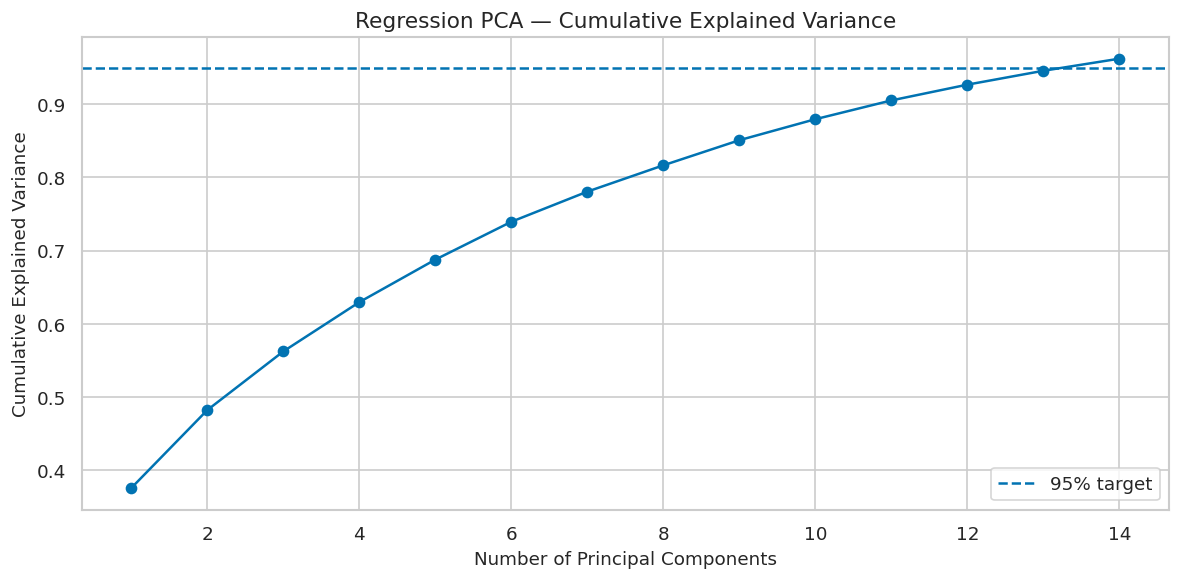

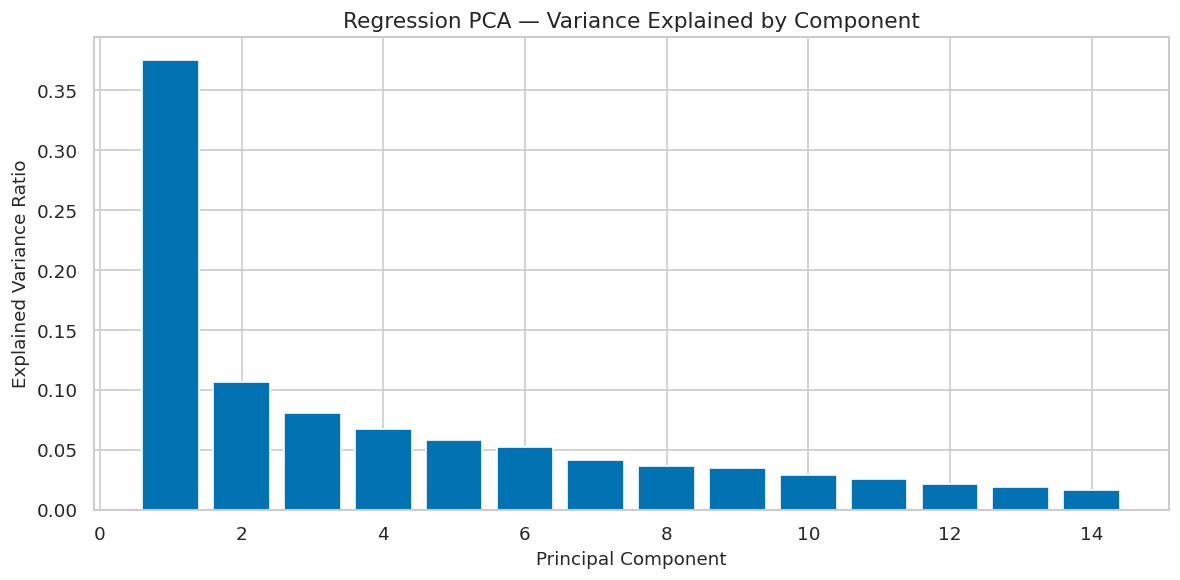

In [58]:
# ============================================================
# 17. PCA FOR REGRESSION
# ============================================================

pca_reg = PCA(n_components=PCA_VARIANCE, svd_solver='full', random_state=RANDOM_STATE)
X_reg_train_pca = pca_reg.fit_transform(X_reg_train_processed)
X_reg_test_pca = pca_reg.transform(X_reg_test_processed)
reg_explained = pca_reg.explained_variance_ratio_
reg_cumulative = np.cumsum(reg_explained)

print(f'Regression PCA components retained: {pca_reg.n_components_}')
print(f'Variance retained: {reg_cumulative[-1]:.4%}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(reg_cumulative)+1), reg_cumulative, marker='o')
ax.axhline(PCA_VARIANCE, linestyle='--', label='95% target')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Regression PCA — Cumulative Explained Variance')
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(reg_explained)+1), reg_explained)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Regression PCA — Variance Explained by Component')
plt.tight_layout(); plt.show()

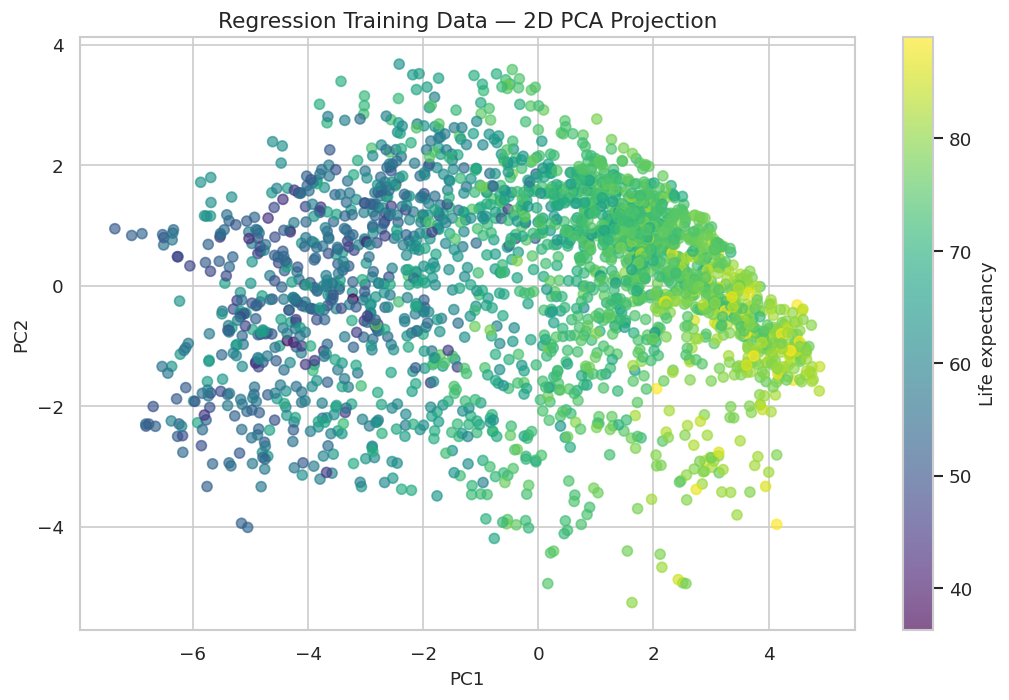

In [59]:
# ============================================================
# 18. 2D PCA VISUALISATION FOR REGRESSION
# ============================================================

if X_reg_train_pca.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(X_reg_train_pca[:, 0], X_reg_train_pca[:, 1], c=y_reg_train, cmap='viridis', alpha=0.65)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title('Regression Training Data — 2D PCA Projection')
    plt.colorbar(sc, ax=ax, label='Life expectancy')
    plt.tight_layout(); plt.show()

Classification PCA components retained: 14
Variance retained: 96.4752%


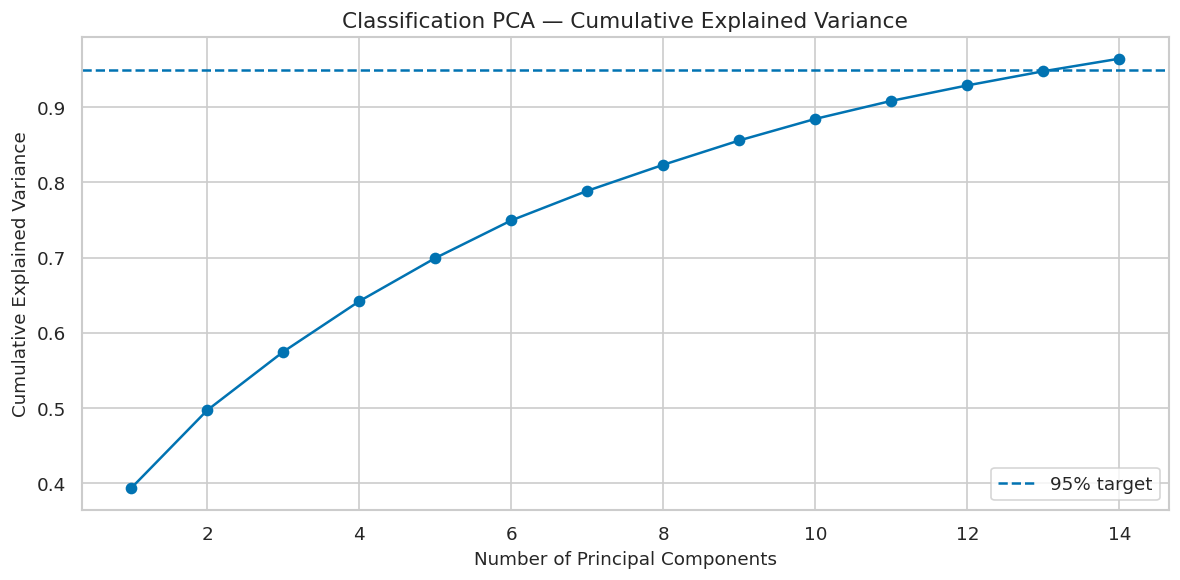

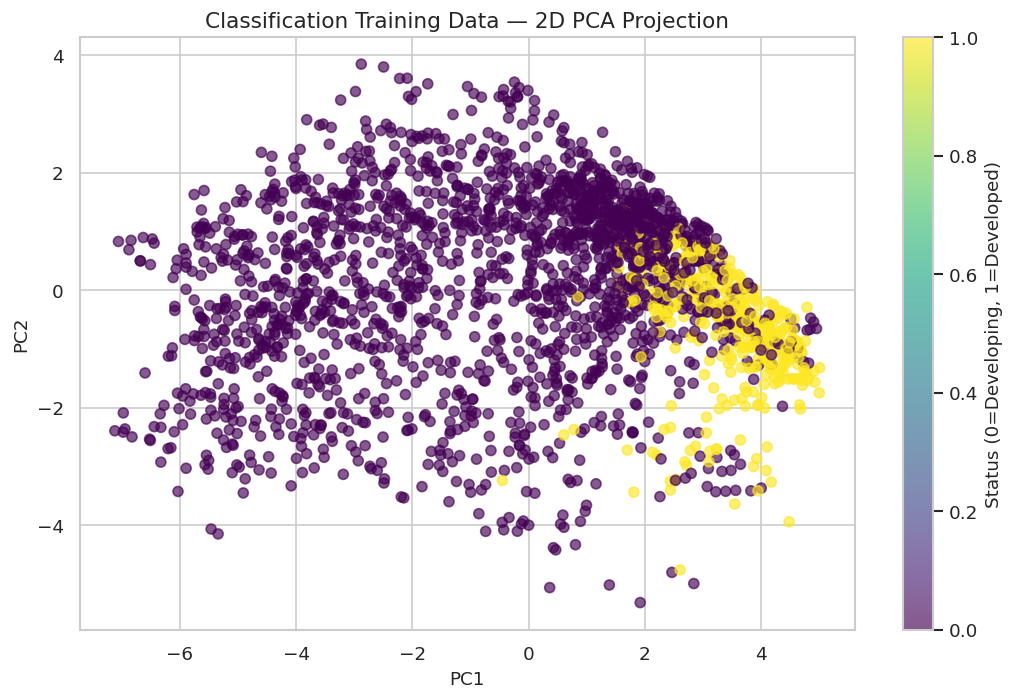

In [60]:
# ============================================================
# 19. PCA FOR CLASSIFICATION
# ============================================================

pca_clf = PCA(n_components=PCA_VARIANCE, svd_solver='full', random_state=RANDOM_STATE)
X_clf_train_pca = pca_clf.fit_transform(X_clf_train_processed)
X_clf_test_pca = pca_clf.transform(X_clf_test_processed)
clf_explained = pca_clf.explained_variance_ratio_
clf_cumulative = np.cumsum(clf_explained)

print(f'Classification PCA components retained: {pca_clf.n_components_}')
print(f'Variance retained: {clf_cumulative[-1]:.4%}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(clf_cumulative)+1), clf_cumulative, marker='o')
ax.axhline(PCA_VARIANCE, linestyle='--', label='95% target')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Classification PCA — Cumulative Explained Variance')
ax.legend(); plt.tight_layout(); plt.show()

if X_clf_train_pca.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(X_clf_train_pca[:, 0], X_clf_train_pca[:, 1], c=y_clf_train, cmap='viridis', alpha=0.65)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title('Classification Training Data — 2D PCA Projection')
    plt.colorbar(sc, ax=ax, label='Status (0=Developing, 1=Developed)')
    plt.tight_layout(); plt.show()

### B3 Observation

PCA reduces the dimensionality of the preprocessed feature space while retaining at least 95% of training variance. The 2D projection is for visual understanding; the 95%-variance PCA representation is used by the Review-1 model comparisons.

# Section C — Regression Track

All ten required regression algorithms use the **same PCA-transformed training/test representation** and the **same held-out test set**.

Mandatory metrics: R², RMSE, MAE, and 5-fold cross-validated R² for the two best-performing models.

In [61]:
# ============================================================
# 20. REGRESSION EVALUATION HELPER
# ============================================================

reg_results = []
reg_predictions = {}
reg_estimators = {}

def evaluate_regressor(name, model, X_train, y_train, X_test, y_test):
    model = clone(model)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = {
        'Model': name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    }
    reg_results.append(result)
    reg_predictions[name] = y_pred
    reg_estimators[name] = model
    print(f"{name:40s} | R²={result['R2']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f}")
    return model, y_pred

## C1 — Regression Algorithms 1–10

1. Linear Regression  
2. Ridge Regression  
3. Lasso Regression  
4. ElasticNet Regression  
5. Polynomial Regression
6. Decision Tree Regressor  
7. Random Forest Regressor  
8. Gradient Boosting Regressor  
9. Support Vector Regressor  
10. K-Nearest Neighbors Regressor

In [82]:
# ============================================================
# 21. REGRESSION 1–10
# ============================================================

lin_reg, _ = evaluate_regressor('1. Linear Regression', LinearRegression(), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
ridge_reg, _ = evaluate_regressor('2. Ridge Regression', Ridge(alpha=1.0), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
lasso_reg, _ = evaluate_regressor('3. Lasso Regression', Lasso(alpha=0.05, max_iter=10000, random_state=RANDOM_STATE), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
elastic_reg, _ = evaluate_regressor('4. ElasticNet Regression', ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)

poly_degree = 2
poly_model = Pipeline([('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)), ('linear', LinearRegression())])
poly_reg, _ = evaluate_regressor(f'5. Polynomial Regression (degree={poly_degree})', poly_model, X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)


dt_reg, _ = evaluate_regressor('6. Decision Tree Regressor', DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
rf_reg, _ = evaluate_regressor('7. Random Forest Regressor', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
gb_reg, _ = evaluate_regressor('8. Gradient Boosting Regressor', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
svr_reg, _ = evaluate_regressor('9. Support Vector Regressor', SVR(C=10, kernel='rbf'), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)
knn_reg, _ = evaluate_regressor('10. K-Nearest Neighbors Regressor', KNeighborsRegressor(n_neighbors=5), X_reg_train_pca, y_reg_train, X_reg_test_pca, y_reg_test)

1. Linear Regression                     | R²=0.8561 | RMSE=3.6658 | MAE=2.7375
2. Ridge Regression                      | R²=0.8561 | RMSE=3.6658 | MAE=2.7375
3. Lasso Regression                      | R²=0.8557 | RMSE=3.6711 | MAE=2.7324
4. ElasticNet Regression                 | R²=0.8556 | RMSE=3.6726 | MAE=2.7310
5. Polynomial Regression (degree=2)      | R²=0.9207 | RMSE=2.7209 | MAE=2.0462
6. Decision Tree Regressor               | R²=0.8325 | RMSE=3.9549 | MAE=2.8553
7. Random Forest Regressor               | R²=0.9054 | RMSE=2.9728 | MAE=2.1176
8. Gradient Boosting Regressor           | R²=0.8946 | RMSE=3.1369 | MAE=2.3203
9. Support Vector Regressor              | R²=0.9361 | RMSE=2.4422 | MAE=1.6222
10. K-Nearest Neighbors Regressor        | R²=0.9056 | RMSE=2.9683 | MAE=2.1026


,Rank,Model,R2,RMSE,MAE
0,1,9. Support Vector Regressor,0.9361,2.4422,1.6222
1,2,5. Polynomial Regression (degree=2),0.9207,2.7209,2.0462
2,3,10. K-Nearest Neighbors Regressor,0.9056,2.9683,2.1026
3,4,7. Random Forest Regressor,0.9054,2.9728,2.1176
4,5,8. Gradient Boosting Regressor,0.8946,3.1369,2.3203
5,6,1. Linear Regression,0.8561,3.6658,2.7375
6,7,2. Ridge Regression,0.8561,3.6658,2.7375
7,8,3. Lasso Regression,0.8557,3.6711,2.7324
8,9,4. ElasticNet Regression,0.8556,3.6726,2.7310
9,10,6. Decision Tree Regressor,0.8325,3.9549,2.8553


Best baseline regression model: 9. Support Vector Regressor | R²=0.9361


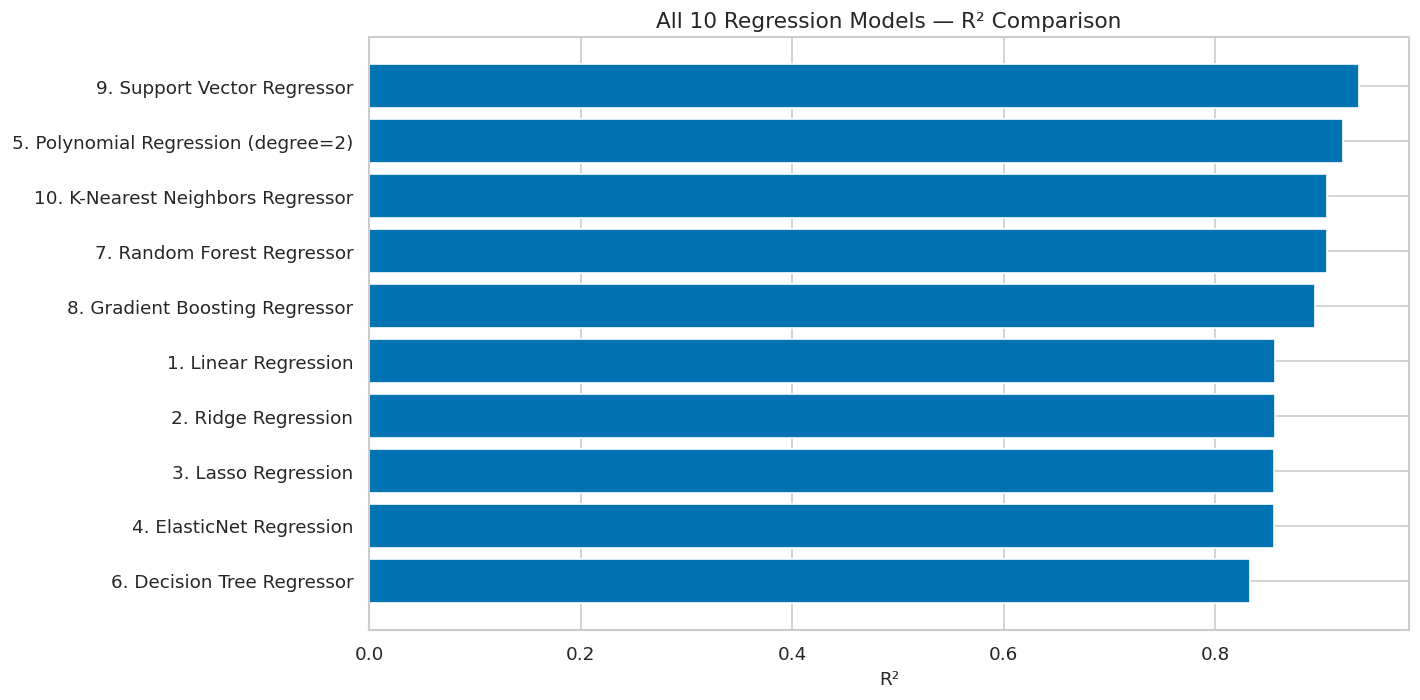

In [64]:
# ============================================================
# 23. C2 — REGRESSION COMPARISON TABLE
# ============================================================

reg_results_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
reg_results_df.insert(0, 'Rank', np.arange(1, len(reg_results_df)+1))
display(reg_results_df.style.format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}'}))

best_reg_baseline = reg_results_df.iloc[0]
print(f"Best baseline regression model: {best_reg_baseline['Model']} | R²={best_reg_baseline['R2']:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = reg_results_df.sort_values('R2')
ax.barh(plot_df['Model'], plot_df['R2'])
ax.set_xlabel('R²'); ax.set_title('All 10 Regression Models — R² Comparison')
plt.tight_layout(); plt.show()

### C2 Observation

The comparison table is the primary regression result. Higher R² is better, while lower RMSE and MAE are better. Because every model uses the same held-out test observations, the comparison is fair.

## C3 — Hyperparameter Tuning

The rubric requires tuning at least two models. We tune Random Forest and Gradient Boosting.

The tuning pipelines use the **raw training DataFrame**, not an already-transformed matrix. GridSearchCV therefore refits preprocessing and PCA inside each CV fold.

In [65]:
# ============================================================
# 24. LEAKAGE-SAFE PIPELINE FACTORY
# ============================================================

def make_reg_pipeline(model):
    return Pipeline([
        ('preprocess', clone(reg_preprocessor)),
        ('pca', PCA(n_components=PCA_VARIANCE, svd_solver='full', random_state=RANDOM_STATE)),
        ('model', model)
    ])

rf_tune_pipeline = make_reg_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
gb_tune_pipeline = make_reg_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE))

rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 8, 12],
    'model__min_samples_split': [2, 5]
}
gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 5]
}

In [66]:
# ============================================================
# 25. GRIDSEARCH — RANDOM FOREST
# ============================================================

rf_grid = GridSearchCV(rf_tune_pipeline, rf_param_grid, scoring='r2', cv=5, n_jobs=-1, refit=True)
rf_grid.fit(X_reg_train, y_reg_train)
rf_best_pipeline = rf_grid.best_estimator_
rf_tuned_pred = rf_best_pipeline.predict(X_reg_test)
rf_tuned_metrics = {'R2': r2_score(y_reg_test, rf_tuned_pred), 'RMSE': np.sqrt(mean_squared_error(y_reg_test, rf_tuned_pred)), 'MAE': mean_absolute_error(y_reg_test, rf_tuned_pred)}
rf_baseline_r2 = float(reg_results_df.loc[reg_results_df['Model']=='7. Random Forest Regressor','R2'].iloc[0])
print('Random Forest best parameters:'); print(rf_grid.best_params_)
print(f'Baseline R²: {rf_baseline_r2:.4f}')
print(f'Tuned R²   : {rf_tuned_metrics["R2"]:.4f}')
print(f'Improvement: {rf_tuned_metrics["R2"] - rf_baseline_r2:+.4f}')

Random Forest best parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Baseline R²: 0.9054
Tuned R²   : 0.9054
Improvement: +0.0000


In [67]:
# ============================================================
# 26. GRIDSEARCH — GRADIENT BOOSTING
# ============================================================

gb_grid = GridSearchCV(gb_tune_pipeline, gb_param_grid, scoring='r2', cv=5, n_jobs=-1, refit=True)
gb_grid.fit(X_reg_train, y_reg_train)
gb_best_pipeline = gb_grid.best_estimator_
gb_tuned_pred = gb_best_pipeline.predict(X_reg_test)
gb_tuned_metrics = {'R2': r2_score(y_reg_test, gb_tuned_pred), 'RMSE': np.sqrt(mean_squared_error(y_reg_test, gb_tuned_pred)), 'MAE': mean_absolute_error(y_reg_test, gb_tuned_pred)}
gb_baseline_r2 = float(reg_results_df.loc[reg_results_df['Model']=='8. Gradient Boosting Regressor','R2'].iloc[0])
print('Gradient Boosting best parameters:'); print(gb_grid.best_params_)
print(f'Baseline R²: {gb_baseline_r2:.4f}')
print(f'Tuned R²   : {gb_tuned_metrics["R2"]:.4f}')
print(f'Improvement: {gb_tuned_metrics["R2"] - gb_baseline_r2:+.4f}')

Gradient Boosting best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Baseline R²: 0.8946
Tuned R²   : 0.9090
Improvement: +0.0144


In [68]:
# ============================================================
# 27. TUNED TEST-SET COMPARISON
# ============================================================

tuned_rows = pd.DataFrame([
    {'Model':'7. Random Forest Regressor (tuned)','R2':rf_tuned_metrics['R2'],'RMSE':rf_tuned_metrics['RMSE'],'MAE':rf_tuned_metrics['MAE']},
    {'Model':'8. Gradient Boosting Regressor (tuned)','R2':gb_tuned_metrics['R2'],'RMSE':gb_tuned_metrics['RMSE'],'MAE':gb_tuned_metrics['MAE']}
])
final_reg_comparison = pd.concat([reg_results_df[['Model','R2','RMSE','MAE']], tuned_rows], ignore_index=True).sort_values('R2', ascending=False).reset_index(drop=True)
final_reg_comparison.insert(0, 'Rank', np.arange(1, len(final_reg_comparison)+1))
display(final_reg_comparison.style.format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}'}))

,Rank,Model,R2,RMSE,MAE
0,1,9. Support Vector Regressor,0.9361,2.4422,1.6222
1,2,5. Polynomial Regression (degree=2),0.9207,2.7209,2.0462
2,3,8. Gradient Boosting Regressor (tuned),0.9090,2.9148,2.1167
3,4,10. K-Nearest Neighbors Regressor,0.9056,2.9683,2.1026
4,5,7. Random Forest Regressor,0.9054,2.9728,2.1176
5,6,7. Random Forest Regressor (tuned),0.9054,2.9728,2.1176
6,7,8. Gradient Boosting Regressor,0.8946,3.1369,2.3203
7,8,1. Linear Regression,0.8561,3.6658,2.7375
8,9,2. Ridge Regression,0.8561,3.6658,2.7375
9,10,3. Lasso Regression,0.8557,3.6711,2.7324


### C3 Observation

The tuning cells calculate and display the actual baseline R², tuned R², improvement, and best parameters after execution. The baseline and tuned values are generated directly from the executed models.

In [69]:
# ============================================================
# 28. 5-FOLD CV FOR THE TWO BEST BASELINE MODELS
# ============================================================

baseline_model_specs = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge Regression': Ridge(alpha=1.0),
    '3. Lasso Regression': Lasso(alpha=0.05, max_iter=10000, random_state=RANDOM_STATE),
    '4. ElasticNet Regression': ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
    '5. Polynomial Regression (degree=2)': Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('linear', LinearRegression())]),
    '6. Decision Tree Regressor': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    '7. Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    '8. Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    '9. Support Vector Regressor': SVR(C=10, kernel='rbf'),
    '10. K-Nearest Neighbors Regressor': KNeighborsRegressor(n_neighbors=5)
}

top_two_names = reg_results_df.head(2)['Model'].tolist()
cv_rows = []
for name in top_two_names:
    pipe = make_reg_pipeline(baseline_model_specs[name])
    scores = cross_val_score(pipe, X_reg_train, y_reg_train, cv=5, scoring='r2', n_jobs=-1)
    cv_rows.append({'Model':name,'CV_R2_Mean':scores.mean(),'CV_R2_Std':scores.std(),'Fold_R2_Scores':np.round(scores,4).tolist()})

cv_df = pd.DataFrame(cv_rows)
display(cv_df[['Model','CV_R2_Mean','CV_R2_Std']].style.format({'CV_R2_Mean':'{:.4f}','CV_R2_Std':'{:.4f}'}))
for row in cv_rows:
    print(f"{row['Model']}: folds={row['Fold_R2_Scores']}")

,Model,CV_R2_Mean,CV_R2_Std
0,9. Support Vector Regressor,0.9263,0.0078
1,5. Polynomial Regression (degree=2),0.9039,0.0108


9. Support Vector Regressor: folds=[0.9241, 0.9345, 0.9348, 0.9244, 0.9137]
5. Polynomial Regression (degree=2): folds=[0.9026, 0.9218, 0.9075, 0.8984, 0.889]


### Why the CV cell uses raw training data

The preprocessing pipeline is recreated for each fold: raw fold → imputation → outlier capping → encoding → scaling → PCA → model. This prevents preprocessing leakage across folds.

## C4 — Residuals, Predicted vs Actual, and Feature Importance

In [70]:
# ============================================================
# 29. SELECT OVERALL BEST MODEL AFTER TUNING
# ============================================================

candidate_predictions = dict(reg_predictions)
candidate_predictions['7. Random Forest Regressor (tuned)'] = rf_tuned_pred
candidate_predictions['8. Gradient Boosting Regressor (tuned)'] = gb_tuned_pred

candidate_metrics = []
for name, pred in candidate_predictions.items():
    candidate_metrics.append({'Model':name,'R2':r2_score(y_reg_test,pred),'RMSE':np.sqrt(mean_squared_error(y_reg_test,pred)),'MAE':mean_absolute_error(y_reg_test,pred)})

candidate_df = pd.DataFrame(candidate_metrics).sort_values('R2', ascending=False).reset_index(drop=True)
display(candidate_df.style.format({'R2':'{:.4f}','RMSE':'{:.4f}','MAE':'{:.4f}'}))
best_final_name = candidate_df.iloc[0]['Model']
best_final_pred = candidate_predictions[best_final_name]
print(f'Overall best Review-1 regression candidate: {best_final_name}')
print(f"R²={r2_score(y_reg_test,best_final_pred):.4f}, RMSE={np.sqrt(mean_squared_error(y_reg_test,best_final_pred)):.4f}, MAE={mean_absolute_error(y_reg_test,best_final_pred):.4f}")

,Model,R2,RMSE,MAE
0,9. Support Vector Regressor,0.9361,2.4422,1.6222
1,5. Polynomial Regression (degree=2),0.9207,2.7209,2.0462
2,8. Gradient Boosting Regressor (tuned),0.9090,2.9148,2.1167
3,10. K-Nearest Neighbors Regressor,0.9056,2.9683,2.1026
4,7. Random Forest Regressor,0.9054,2.9728,2.1176
5,7. Random Forest Regressor (tuned),0.9054,2.9728,2.1176
6,8. Gradient Boosting Regressor,0.8946,3.1369,2.3203
7,1. Linear Regression,0.8561,3.6658,2.7375
8,2. Ridge Regression,0.8561,3.6658,2.7375
9,3. Lasso Regression,0.8557,3.6711,2.7324


Overall best Review-1 regression candidate: 9. Support Vector Regressor
R²=0.9361, RMSE=2.4422, MAE=1.6222


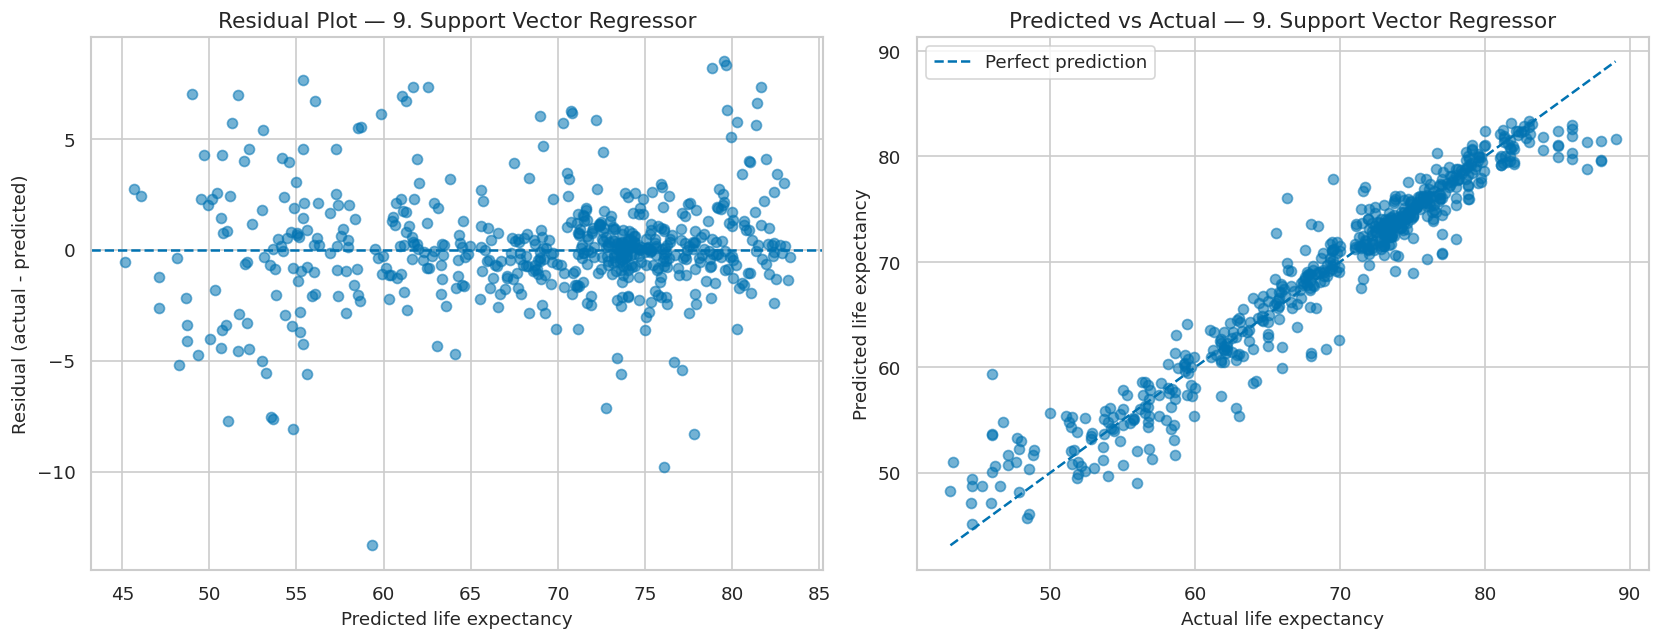

In [71]:
# ============================================================
# 30. RESIDUAL + PREDICTED VS ACTUAL
# ============================================================

residuals = y_reg_test.to_numpy() - best_final_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(best_final_pred, residuals, alpha=0.55)
axes[0].axhline(0, linestyle='--')
axes[0].set_title(f'Residual Plot — {best_final_name}')
axes[0].set_xlabel('Predicted life expectancy')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[1].scatter(y_reg_test, best_final_pred, alpha=0.55)
lims=[min(y_reg_test.min(),best_final_pred.min()),max(y_reg_test.max(),best_final_pred.max())]
axes[1].plot(lims,lims,linestyle='--',label='Perfect prediction')
axes[1].set_title(f'Predicted vs Actual — {best_final_name}')
axes[1].set_xlabel('Actual life expectancy')
axes[1].set_ylabel('Predicted life expectancy')
axes[1].legend()
plt.tight_layout(); plt.show()

,Feature,Importance_Mean,Importance_Std
13,HIV_AIDS,0.107090,0.010254
2,Adult_Mortality,0.070232,0.004869
20,Mortality_Burden,0.059918,0.006028
18,Income_composition_of_resources,0.042055,0.004410
19,Schooling,0.034475,0.005571
4,Alcohol,0.027859,0.003803
8,BMI,0.021410,0.003527
17,Thinness_5_9_years,0.021299,0.002474
16,thinness 1-19 years,0.020213,0.002884
11,Total_expenditure,0.018022,0.004074


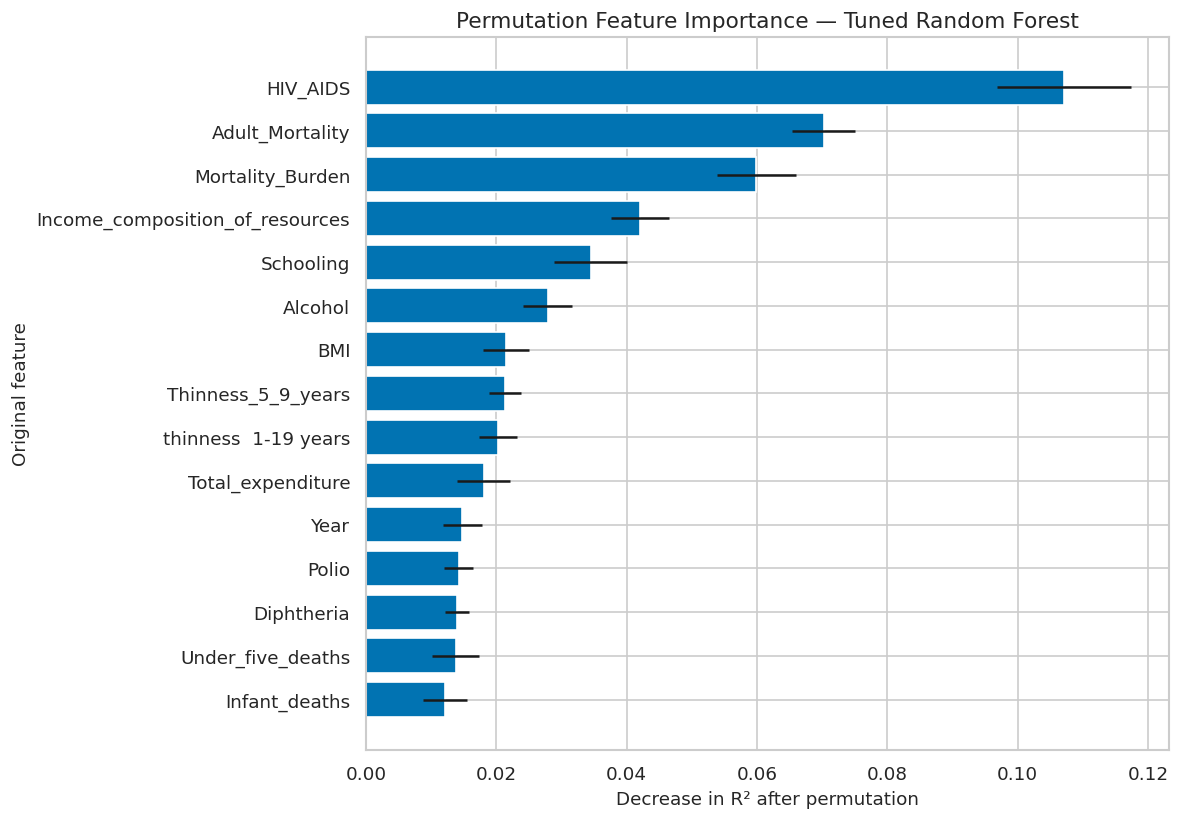

In [72]:
# ============================================================
# 31. TREE-BASED FEATURE IMPORTANCE VIA PERMUTATION IMPORTANCE
# ============================================================

# The tuned Random Forest is used because the rubric explicitly asks for
# feature importance from a tree-based model.
perm = permutation_importance(
    rf_best_pipeline,
    X_reg_test,
    y_reg_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='r2',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_reg_test.columns,
    'Importance_Mean': perm.importances_mean,
    'Importance_Std': perm.importances_std
}).sort_values('Importance_Mean', ascending=False)

display(perm_df.head(15))
top_perm = perm_df.head(15).sort_values('Importance_Mean')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_perm['Feature'], top_perm['Importance_Mean'], xerr=top_perm['Importance_Std'])
ax.set_xlabel('Decrease in R² after permutation')
ax.set_ylabel('Original feature')
ax.set_title('Permutation Feature Importance — Tuned Random Forest')
plt.tight_layout(); plt.show()

### C4 Observation

Permutation importance is used instead of directly plotting PCA-component importances. The model internally uses PCA, but permutation importance measures the effect of disturbing each original test-set feature on the complete pipeline, making the result easier to explain in the viva.

# Section D — Classification Track, Part A

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

Target: `0 = Developing`, `1 = Developed`.

In [73]:
# ============================================================
# 32. CLASSIFICATION EVALUATION HELPER
# ============================================================

clf_results=[]
clf_predictions={}

def evaluate_classifier(name, model, X_train, y_train, X_test, y_test):
    model=clone(model)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    if hasattr(model,'predict_proba'):
        y_score=model.predict_proba(X_test)[:,1]
    else:
        y_score=model.decision_function(X_test)
    result={
        'Model':name,
        'Accuracy':accuracy_score(y_test,y_pred),
        'Precision_weighted':precision_score(y_test,y_pred,average='weighted',zero_division=0),
        'Recall_weighted':recall_score(y_test,y_pred,average='weighted',zero_division=0),
        'F1_weighted':f1_score(y_test,y_pred,average='weighted',zero_division=0),
        'ROC_AUC':roc_auc_score(y_test,y_score)
    }
    clf_results.append(result)
    clf_predictions[name]=(model,y_pred,y_score)
    print(f"{name:30s} | Accuracy={result['Accuracy']:.4f} | F1={result['F1_weighted']:.4f} | ROC-AUC={result['ROC_AUC']:.4f}")
    return model,y_pred,y_score

## D1 — Classification Algorithms 1–5


In [74]:
# ============================================================
# 33. FIVE PART-A CLASSIFIERS
# ============================================================

log_clf,y_log,s_log=evaluate_classifier('1. Logistic Regression',LogisticRegression(max_iter=2000,random_state=RANDOM_STATE),X_clf_train_pca,y_clf_train,X_clf_test_pca,y_clf_test)
knn_clf,y_knn,s_knn=evaluate_classifier('2. K-Nearest Neighbors',KNeighborsClassifier(n_neighbors=5),X_clf_train_pca,y_clf_train,X_clf_test_pca,y_clf_test)
nb_clf,y_nb,s_nb=evaluate_classifier('3. Gaussian Naive Bayes',GaussianNB(),X_clf_train_pca,y_clf_train,X_clf_test_pca,y_clf_test)
dt_clf,y_dt,s_dt=evaluate_classifier('4. Decision Tree Classifier',DecisionTreeClassifier(max_depth=6,random_state=RANDOM_STATE),X_clf_train_pca,y_clf_train,X_clf_test_pca,y_clf_test)
svc_clf,y_svc,s_svc=evaluate_classifier('5. Support Vector Machine',SVC(C=1.0,kernel='rbf',probability=True,random_state=RANDOM_STATE),X_clf_train_pca,y_clf_train,X_clf_test_pca,y_clf_test)

1. Logistic Regression         | Accuracy=0.9303 | F1=0.9293 | ROC-AUC=0.9683
2. K-Nearest Neighbors         | Accuracy=0.9456 | F1=0.9454 | ROC-AUC=0.9661
3. Gaussian Naive Bayes        | Accuracy=0.8929 | F1=0.8939 | ROC-AUC=0.9467
4. Decision Tree Classifier    | Accuracy=0.9320 | F1=0.9320 | ROC-AUC=0.9336
5. Support Vector Machine      | Accuracy=0.9456 | F1=0.9454 | ROC-AUC=0.9728


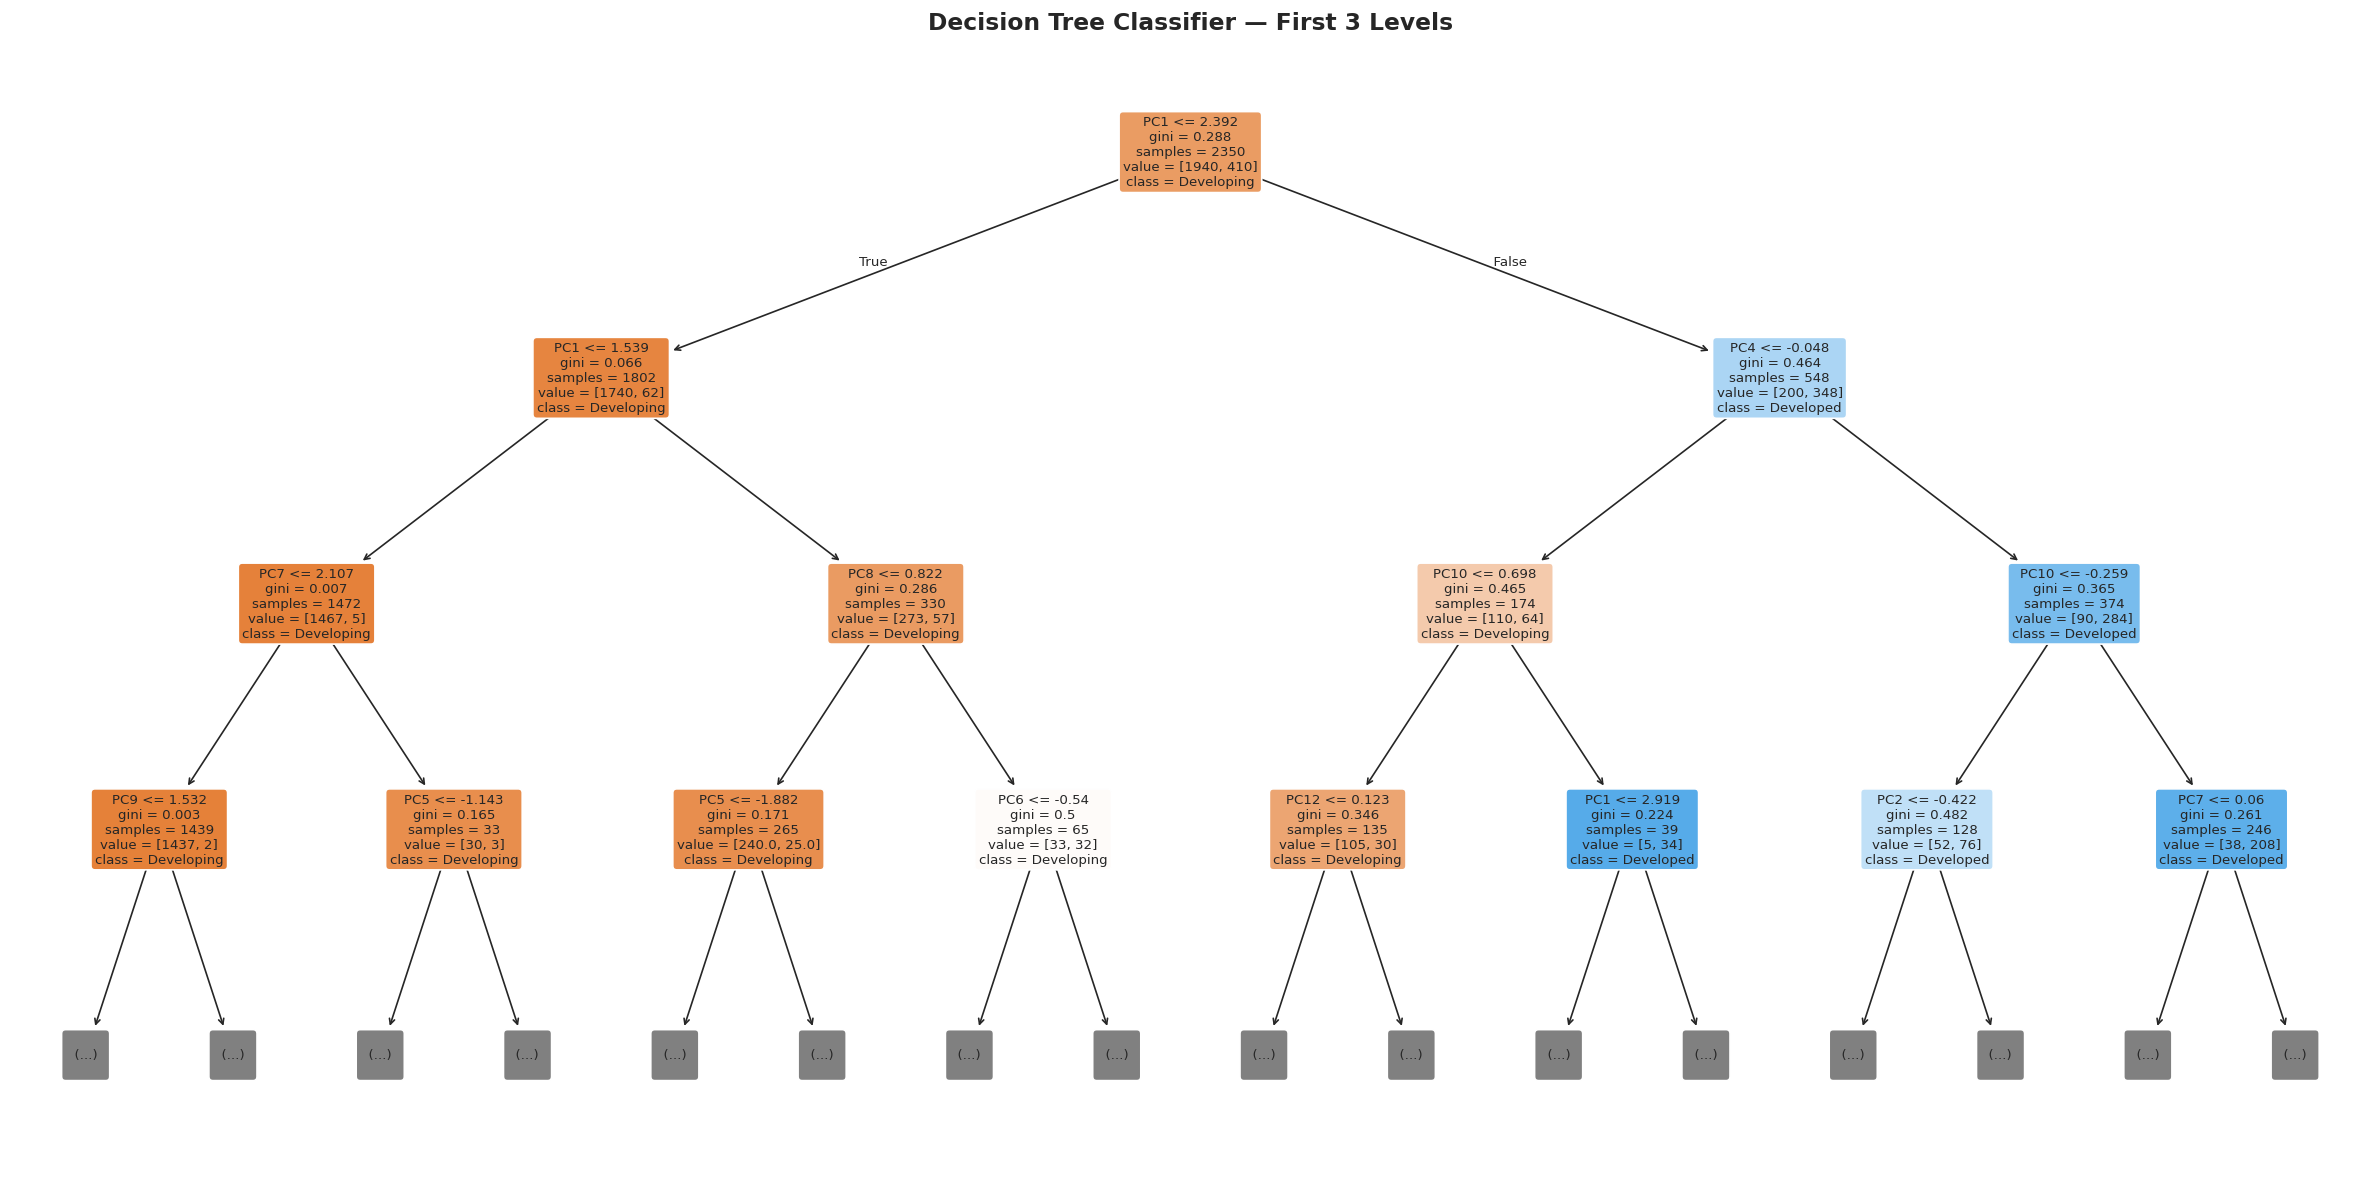

In [75]:
# ============================================================
# 34. DECISION TREE VISUALISATION
# ============================================================

# The tree uses the same PCA representation as the other Part-A classifiers.
# Only the first three levels are displayed so the plot remains readable.

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_clf,
    feature_names=[f"PC{i+1}" for i in range(X_clf_train_pca.shape[1])],
    class_names=["Developing", "Developed"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
    ax=ax
)
ax.set_title("Decision Tree Classifier — First 3 Levels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [76]:
# ============================================================
# 35. CLASSIFICATION COMPARISON TABLE
# ============================================================

clf_results_df=pd.DataFrame(clf_results).sort_values('F1_weighted',ascending=False).reset_index(drop=True)
clf_results_df.insert(0,'Rank',np.arange(1,len(clf_results_df)+1))
display(clf_results_df.style.format({'Accuracy':'{:.4f}','Precision_weighted':'{:.4f}','Recall_weighted':'{:.4f}','F1_weighted':'{:.4f}','ROC_AUC':'{:.4f}'}))
best_clf=clf_results_df.iloc[0]
print(f"Best Review-1 Part-A classifier: {best_clf['Model']} | Weighted F1={best_clf['F1_weighted']:.4f}")

,Rank,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
0,1,2. K-Nearest Neighbors,0.9456,0.9452,0.9456,0.9454,0.9661
1,2,5. Support Vector Machine,0.9456,0.9452,0.9456,0.9454,0.9728
2,3,4. Decision Tree Classifier,0.9320,0.9320,0.9320,0.9320,0.9336
3,4,1. Logistic Regression,0.9303,0.9287,0.9303,0.9293,0.9683
4,5,3. Gaussian Naive Bayes,0.8929,0.8950,0.8929,0.8939,0.9467


Best Review-1 Part-A classifier: 2. K-Nearest Neighbors | Weighted F1=0.9454


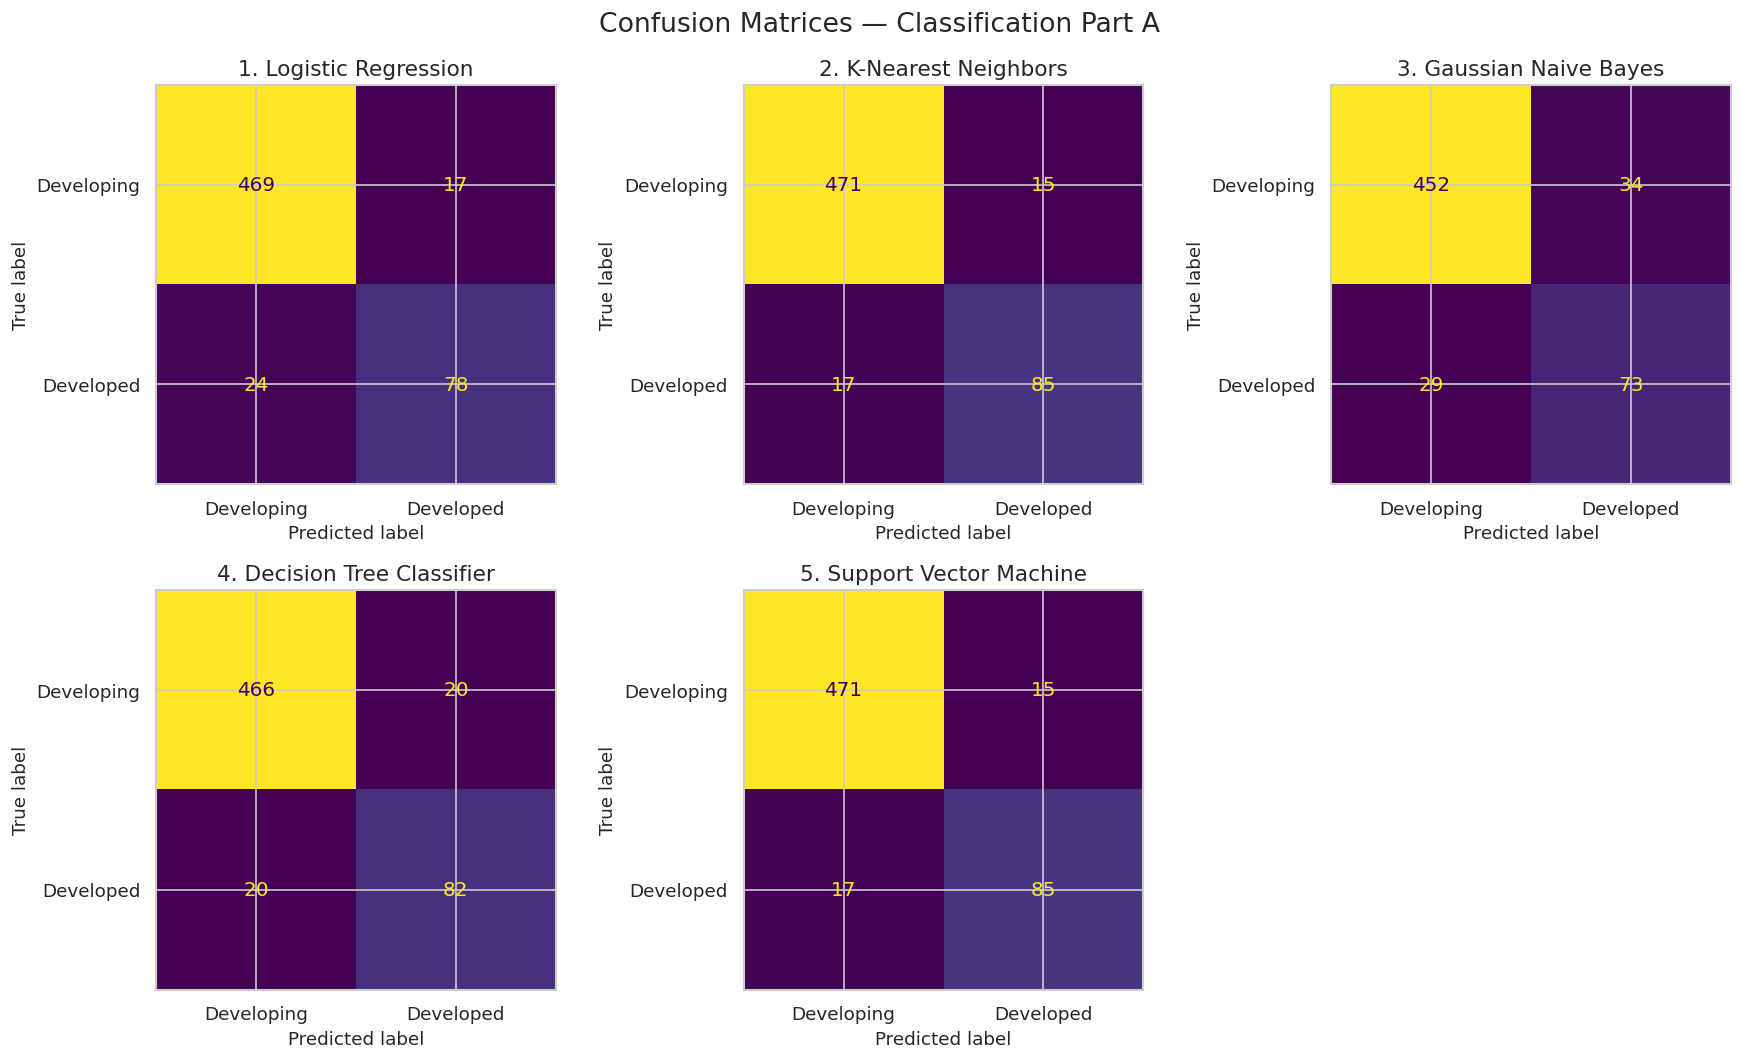

In [77]:
# ============================================================
# 36. CONFUSION MATRICES
# ============================================================

fig, axes=plt.subplots(2,3,figsize=(15,9)); axes=axes.flatten()
for i,(name,(model,y_pred,y_score)) in enumerate(clf_predictions.items()):
    cm=confusion_matrix(y_clf_test,y_pred)
    disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Developing','Developed'])
    disp.plot(ax=axes[i],colorbar=False); axes[i].set_title(name)
axes[-1].set_visible(False)
fig.suptitle('Confusion Matrices — Classification Part A',fontsize=16)
plt.tight_layout(); plt.show()

In [78]:
# ============================================================
# 37. KNN SENSITIVITY CHECK
# ============================================================

k_rows=[]
for k in [3,5,7,9,11]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_clf_train_pca,y_clf_train)
    pred=knn.predict(X_clf_test_pca)
    k_rows.append({'k':k,'Accuracy':accuracy_score(y_clf_test,pred),'Weighted_F1':f1_score(y_clf_test,pred,average='weighted')})
display(pd.DataFrame(k_rows).round(4))

,k,Accuracy,Weighted_F1
0,3,0.9490,0.9490
1,5,0.9456,0.9454
2,7,0.9422,0.9419
3,9,0.9422,0.9417
4,11,0.9354,0.9346


### D2 Observation

The classification table is a **preliminary Part-A comparison** because the remaining five classification algorithms belong to Review 2. Confusion matrices should be used to explain true positives, true negatives, false positives, false negatives, and minority-class performance.

In [83]:
# ============================================================
# 38. FINAL REVIEW-1 FINDINGS
# ============================================================

best_baseline=reg_results_df.iloc[0]
best_final=candidate_df.iloc[0]
best_classifier=clf_results_df.iloc[0]
rf_tune_improvement=rf_tuned_metrics['R2']-rf_baseline_r2
gb_tune_improvement=gb_tuned_metrics['R2']-gb_baseline_r2
top_feature=perm_df.iloc[0]['Feature']
top_feature_importance=perm_df.iloc[0]['Importance_Mean']

print('='*78)
print('REVIEW 1 — FINAL KEY FINDINGS')
print('='*78)
print('\n1. Regression')
print(f"Best baseline: {best_baseline['Model']} (R²={best_baseline['R2']:.4f}, RMSE={best_baseline['RMSE']:.4f}, MAE={best_baseline['MAE']:.4f})")
print(f"Best after tuning: {best_final['Model']} (R²={best_final['R2']:.4f}, RMSE={best_final['RMSE']:.4f}, MAE={best_final['MAE']:.4f})")
print('\n2. Hyperparameter tuning')
print(f'Random Forest R² improvement: {rf_tune_improvement:+.4f}')
print(f'Gradient Boosting R² improvement: {gb_tune_improvement:+.4f}')
print('\n3. Cross-validation')
for _,row in cv_df.iterrows():
    print(f"{row['Model']}: mean CV R²={row['CV_R2_Mean']:.4f}, std={row['CV_R2_Std']:.4f}")
print('\n4. PCA')
print(f'Regression PCA: {pca_reg.n_components_} components, {reg_cumulative[-1]:.2%} variance retained.')
print(f'Classification PCA: {pca_clf.n_components_} components, {clf_cumulative[-1]:.2%} variance retained.')
print('\n5. Feature importance')
print(f'Top permutation feature: {top_feature} (importance={top_feature_importance:.4f})')
print('\n6. Classification Part A')
print(f"Best classifier: {best_classifier['Model']} (Accuracy={best_classifier['Accuracy']:.4f}, Weighted F1={best_classifier['F1_weighted']:.4f}, ROC-AUC={best_classifier['ROC_AUC']:.4f})")
print('\n7. Data quality')
print(f'Original rows loaded: {len(df_raw)}; rows used for regression after dropping missing target: {len(reg_df)}.')
print('Missing predictors are handled inside train-only preprocessing pipelines.')
print('='*78)

REVIEW 1 — FINAL KEY FINDINGS

1. Regression
Best baseline: 9. Support Vector Regressor (R²=0.9361, RMSE=2.4422, MAE=1.6222)
Best after tuning: 9. Support Vector Regressor (R²=0.9361, RMSE=2.4422, MAE=1.6222)

2. Hyperparameter tuning
Random Forest R² improvement: +0.0000
Gradient Boosting R² improvement: +0.0144

3. Cross-validation
9. Support Vector Regressor: mean CV R²=0.9263, std=0.0078
5. Polynomial Regression (degree=2): mean CV R²=0.9039, std=0.0108

4. PCA
Regression PCA: 14 components, 96.24% variance retained.
Classification PCA: 14 components, 96.48% variance retained.

5. Feature importance
Top permutation feature: HIV_AIDS (importance=0.1071)

6. Classification Part A
Best classifier: 2. K-Nearest Neighbors (Accuracy=0.9456, Weighted F1=0.9454, ROC-AUC=0.9661)

7. Data quality
Original rows loaded: 2942; rows used for regression after dropping missing target: 2928.
Missing predictors are handled inside train-only preprocessing pipelines.
